# Ramsey interferometry — the standard quantum limit, simulated end to end

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A caesium clock, a strontium optical lattice clock and an atom interferometer measuring gravity all run the same four-step
programme:

1. **prepare** $N$ atoms in a well-defined quantum state;
2. **encode** the quantity you want to know into a phase $\varphi$ that the atoms accumulate;
3. **measure** the atoms;
4. **estimate** $\varphi$ from the measurement record, and quote an uncertainty.

Norman Ramsey's *method of separated oscillating fields* (1950) is the standard implementation of steps 1–3. Two short
resonant pulses, separated by a long period of free evolution, convert an unknown detuning between the laser (or microwave)
frequency and the atomic transition frequency into a number of atoms found in the excited state. Atomic clocks use this
sequence or close relatives of it; the review by Ludlow and co-workers (Section 20) describes how it is done in the
laboratory.

This notebook simulates that protocol **end to end**: we build the state with the einsum engine, encode a phase, sample real
measurement records (bit strings, one bit per atom per repetition), feed them to two estimators, and compare the *measured*
uncertainty with the *theoretical* bounds. Every claim about a sensitivity is checked against simulated data.

The central result is a number. With $N$ uncorrelated atoms and $M$ repetitions of the experiment, the phase uncertainty of the
Ramsey protocol is

$$\Delta\varphi=\frac{1}{\sqrt{NM}},$$

the **standard quantum limit** (SQL). We will derive it three different ways — error propagation, classical Fisher information,
quantum Fisher information — see all three give the same answer, and then watch several thousand simulated experiments per
data point reproduce it to about one per cent. We will also see where the protocol *fails*: at the extrema of the
fringe, and beyond a phase window of width $\pi$.

The last part of the notebook adds the effect that limits the interrogation time of a clock: **decoherence during the
interrogation**.
Dephasing at a rate $\gamma$ multiplies the fringe contrast by $e^{-\gamma T}$ after an interrogation time $T$. Longer
interrogation means more phase per repetition but less contrast, and at a fixed total experiment time the compromise has a
sharp optimum,

$$T_{\mathrm{opt}}=\frac{1}{2\gamma},$$

which we derive and then verify on simulated data. Through it, the coherence time sets the best achievable frequency
resolution.

**Road map.**

1. A one-page recap of the estimation theory we import from notebooks 29 and 30 (Section 3).
2. The physics: two-level atom, detuning, rotating frame, the collective spin, the Bloch-sphere picture (Section 4).
3. The protocol, with the full algebra for one atom and for $N$ atoms: the signal $\langle J_z\rangle(\varphi)$ (Section 5).
4. Projection noise and error propagation: $\Delta\varphi=1/\sqrt N$, and why the naive formula breaks at the fringe extrema
   (Section 6).
5. Fisher information of the readout: the classical Fisher information of the binomial outcome distribution equals $N$ at
   every $\varphi$ strictly inside the fringe and equals the quantum Fisher information — counting atoms is an **optimal**
   measurement (Section 7).
6. Simulation: the circuit, sampled bit strings, two estimators, histograms, bias, and the measured $\Delta\varphi$ against
   $1/\sqrt{NM}$ over $N$ and $M$ (Sections 8–12).
7. The failure modes: fringe extrema and phase wrapping (Sections 13–14).
8. Dephasing during the interrogation, the contrast $e^{-\gamma T}$, and the optimal interrogation time (Sections 15–16).
9. The cost of the two samplers, measured (Section 17).

### What you will learn

*Physics*

* what a Ramsey sequence does, why the accumulated phase is $\varphi=\delta T$, and what "mid-fringe operation" means;
* the coherent spin state as the quantum-mechanical analogue of a classical spin, and its **projection noise**;
* the standard quantum limit $\Delta\varphi=1/\sqrt{NM}$, derived independently from error propagation and from Fisher
  information;
* why atom counting is an optimal measurement for this state, and under which conditions that optimality holds;
* how dephasing enters as a contrast factor $e^{-\gamma T}$ and fixes the optimal interrogation time of a clock.

*Numerical methods*

* turning a physical protocol into a sampling problem: Born-rule sampling of bit strings in addition to expectation values;
* two estimators — method of moments and maximum likelihood — and the fact that here they coincide because the total atom
  count is a **sufficient statistic**;
* measuring a standard deviation from a finite ensemble of experiments, and putting an error bar on the standard deviation
  itself;
* fitting a power law on a log-log plot and reading off the exponent;
* the difference between an *unbiased* estimator and a *good* one, how large the bias is away from mid-fringe
  ($\approx-\cot\varphi/(2NM)$), and how it grows near the edges of a parameter range.

*Implementation practice*

* `vmap` over shots and over independent experiments with explicit, deterministically split PRNG keys;
* static versus traced arguments: qubit counts and shot numbers are Python integers, angles are traced;
* why a naive `vmap` over the engine's categorical sampler can eat gigabytes, and the two ways out (chunking, or exploiting a
  product structure that has been *verified* numerically);
* writing the interpretation of a figure only after looking at the numbers it contains.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb);
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus operators;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): the Born rule and sampling bit strings;
* [29 — quantum Fisher information](./29_quantum_fisher_information.ipynb): estimators, classical Fisher information, the
  Cramér–Rao bound, $F_Q=4\,\mathrm{Var}(G)$ for pure states;
* [30 — QFI from the SLD: prepare, encode, estimate](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb): the
  symmetric-logarithmic-derivative formula for mixed states, which we use in Section 15.

**What comes next.** [32 — GHZ interferometry and the Heisenberg limit](./32_ghz_interferometry_heisenberg_limit.ipynb)
replaces the coherent spin state by a GHZ state and reaches $\Delta\varphi=1/(N\sqrt M)$.

**Conventions.** Atom $q$ = tensor axis $q$, counted from $0$. The ground state is $\vert0\rangle$, the $+1$ eigenstate of $Z$;
the excited state is $\vert1\rangle$. Collective spin operators are $J_a=\tfrac12\sum_q\sigma^a_q$ with $a=x,y,z$, so that
$J_z=\tfrac12\sum_qZ_q$ has eigenvalues $-N/2,\dots,+N/2$. We set $\hbar=1$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We need: single-qubit rotations `ry`, `rz`; `apply_gate` to put them on one tensor axis; `sample_bitstrings` for Born-rule
sampling of full measurement records; `spin_moments` for $\langle J_a\rangle$ and the covariance matrix; `qfi_pure` and
`qfi_mixed` for the two Fisher-information benchmarks; the density-tensor machinery and the dephasing / amplitude-damping
Kraus channels for the noisy sections. `apply_kraus_mcwf` (quantum trajectories) and `oat_evolve` (one-axis twisting) are
recapped for Exercises 5 and 8. Everything specific to Ramsey interferometry is written below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


In [3]:
# ==============================================================================
# PLOT STYLE + tiny helpers used throughout this notebook
# ==============================================================================
from jax.scipy.special import gammaln          # exact binomial weights in Section 13 (log-gamma, no overflow)

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def fit_power_law(x, y, rel_err=None):
    """Least-squares fit of y = A x^s on a log-log scale; returns (A, s, sigma_s).

    MATH  log y = log A + s log x  -- an ordinary straight-line fit of the logarithms.
          Every y here is a sample standard deviation from the SAME number K of experiments, so all
          points carry the same RELATIVE error eps = 1/sqrt(2(K-1)), i.e. the same ABSOLUTE error
          eps on log y.  With equal weights the slope error is then exactly
              sigma_s = eps / sqrt( sum_i (log x_i - <log x>)^2 ),
          which is what makes "the fitted exponent is -0.508" a statement rather than a decoration.
          `rel_err = None` -> sigma_s is returned as nan (no error model supplied).
    """
    lx, ly = np.log(np.asarray(x, float)), np.log(np.asarray(y, float))
    s, lnA = np.polyfit(lx, ly, 1)
    sig = np.nan if rel_err is None else float(rel_err) / np.sqrt(np.sum((lx - lx.mean()) ** 2))
    return float(np.exp(lnA)), float(s), float(sig)


def std_of_std(sigma, n):
    """Standard error OF a sample standard deviation estimated from n samples:  sigma / sqrt(2(n-1)).
    (Exact for Gaussian data; we use it for the error bars on every measured `Delta phi`.)"""
    return np.asarray(sigma) / np.sqrt(2.0 * (n - 1))

## 3. Results imported from estimation theory

Notebooks [29](./29_quantum_fisher_information.ipynb) and
[30](./30_qfi_from_the_sld_prepare_encode_estimate.ipynb) built the machinery; this section only restates the four facts we
use, so that the present notebook can be read on its own. Nothing here is re-derived.

**(i) Estimator, bias, uncertainty.** An experiment produces data $x$ distributed according to $p(x\vert\varphi)$. An
*estimator* is any function $\hat\varphi(x)$. It is **unbiased** if $\mathbb E[\hat\varphi]=\varphi$, and its uncertainty is
the standard deviation $\Delta\varphi=\sqrt{\mathrm{Var}(\hat\varphi)}$.

**(ii) Classical Fisher information.** For a probability distribution $p(x\vert\varphi)$,

$$F_C(\varphi)=\sum_x\frac{1}{p(x\vert\varphi)}\left(\frac{\partial p(x\vert\varphi)}{\partial\varphi}\right)^{\!2}. \tag{1}$$

It is **additive** over independent repetitions: $M$ repetitions of the same experiment carry $MF_C$.

**(iii) Cramér–Rao bound.** Every unbiased estimator obeys

$$\Delta\varphi\ \ge\ \frac{1}{\sqrt{M\,F_C(\varphi)}}. \tag{2}$$

The bound holds under two conditions (notebook 29, Section 4.7): the estimator is (locally) unbiased,
$\partial_\varphi\mathbb E[\hat\varphi]=1$ at the working point, and the model is *regular* there, meaning that the set of
outcomes with non-zero probability does not change with $\varphi$. It is *attainable* asymptotically: under the same
regularity conditions the maximum-likelihood estimator has a bias that falls like $1/M$ and a variance that approaches
$1/(MF_C)$ as $M\to\infty$. Both conditions fail somewhere in this notebook (Sections 7.1 and 13), and the bias at finite
$M$ is measured in Section 11.1.

**(iv) Quantum Fisher information.** Maximising $F_C$ over all possible measurements of the state $\rho_\varphi$ gives the
quantum Fisher information $F_Q[\rho_\varphi]$, and hence $\Delta\varphi\ge1/\sqrt{MF_Q}$ (the *quantum* Cramér–Rao bound).
For a **pure** state $\vert\psi\rangle$ whose phase is imprinted by $e^{-i\varphi G}$,

$$F_Q=4\,\mathrm{Var}(G)=4\big(\langle G^2\rangle-\langle G\rangle^2\big). \tag{3}$$

For a **mixed** state, $F_Q$ follows from the symmetric logarithmic derivative; in the eigenbasis $\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$,

$$F_Q=2\sum_{m,n:\ \lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,\vert\langle m\vert G\vert n\rangle\vert^2. \tag{4}$$

Equations (3) and (4) are implemented in the engine as `qfi_pure` and `qfi_mixed`; we use them as *benchmarks* for the
measured sensitivities. The quantum Cramér–Rao bound inherits the conditions of (iii), and measuring the $M$ copies
*jointly* does not beat it, because the quantum Fisher information is additive over independent copies,
$F_Q[\rho_\varphi^{\otimes M}]=MF_Q[\rho_\varphi]$.

**What is counted.** As in notebook 29 (Section 7.5), the resource is the number of single-atom phase imprints,
$\nu=NM$: each of the $N$ atoms acquires the phase once per repetition, and the protocol is repeated $M$ times. The
standard quantum limit is $\Delta\varphi=1/\sqrt\nu$ and the Heisenberg limit $\Delta\varphi=\sqrt M/\nu$. The
interrogation time does not enter this count; it enters only in Section 16, where the quantity to be estimated is a
frequency and the resource is a fixed total time.

> **Numerical practice.** A bound is a claim about *every* estimator, so a simulation can confirm it only by exhibiting
> an estimator that comes close; it cannot prove it. Throughout this notebook the logic is: derive the bound, build an
> estimator, measure its spread over many independent experiments, and check that the measured spread sits on the bound
> and never below it. A measured point *below* a Cramér–Rao bound means that the estimator is biased there, and the bias
> is the first thing to check.

## 4. The physics: from a detuning to a phase

### 4.1 One atom, two levels, one rotating frame

Model each atom as a two-level system with ground state $\vert0\rangle$ and excited state $\vert1\rangle$ separated by the
transition frequency $\omega_0$. We interrogate it with a field of frequency $\omega_L$ and define the **detuning**

$$\delta=\omega_L-\omega_0 .$$

The quantity a clock wants to know is $\omega_0$; since $\omega_L$ is set by the experimenter, knowing $\delta$ is the same
thing. In the frame rotating at $\omega_L$ (the standard rotating-wave picture; see any quantum-optics text) the atomic
Hamiltonian becomes, *when the field is off*,

$$H=-\delta\,\vert1\rangle\langle1\vert=-\delta\,\frac{\mathbb 1-Z}{2}=\text{const}+\frac{\delta}{2}Z .$$

Dropping the constant (it only contributes an unobservable global phase) and writing $J_z^{(1)}=Z/2$ for one atom,

$$H=\delta\,J_z,\qquad\text{so after a free evolution of duration }T:\quad U=e^{-i\delta T J_z}=e^{-i\varphi J_z},\quad
\boxed{\ \varphi=\delta\,T\ } \tag{5}$$

This is how interferometry measures frequencies: the unknown $\delta$ is converted into a phase, and the phase grows
linearly with the interrogation time.

### 4.2 Many atoms: the collective spin

With $N$ identical atoms, and a field that addresses them all identically, only the **collective** spin operators appear:

$$J_x=\frac12\sum_{q=0}^{N-1}X_q,\qquad J_y=\frac12\sum_qY_q,\qquad J_z=\frac12\sum_qZ_q .$$

They satisfy the angular-momentum algebra $[J_x,J_y]=iJ_z$ and cyclic permutations, so the state of the ensemble can be
pictured as a spin of length $J=N/2$ on a sphere of radius $N/2$ — the **Bloch sphere of the collective spin**. The free
evolution (5) becomes $e^{-i\varphi J_z}$: a rotation of that big spin about the $z$ axis by the angle $\varphi$. A global
pulse resonant with the transition is a rotation about an axis in the equatorial plane.

Two facts make this picture quantitative:

* $J_z$ counts atoms. If $n_1$ of the $N$ atoms are found in $\vert1\rangle$, then $J_z=\tfrac12(N-n_1)-\tfrac12 n_1=\tfrac N2-n_1$.
  **Measuring $J_z$ = counting excited atoms**, which is exactly what a camera or a photomultiplier does.
* the uncertainty relation $\Delta J_x\,\Delta J_y\ge\tfrac12\vert\langle J_z\rangle\vert$ forbids a perfectly sharp arrow.
  The tip of the collective spin always carries a fuzzy patch, and the size of that patch is the **projection noise** of
  Section 6.

> **Physics insight.** Everything in this chapter is a statement about *how much area that fuzzy patch occupies and in which
> direction it is elongated*. Ramsey interferometry uses a round patch of area set by $N$ (this notebook); GHZ interferometry
> ([notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb)) abandons the picture of a spin with a small patch altogether;
> spin squeezing ([notebook 33](./33_spin_squeezing_one_axis_twisting.ipynb)) keeps the arrow but squashes the patch in the
> useful direction.

## 5. The Ramsey protocol

### 5.1 The four steps

| step | operation | what it does to the collective spin |
|---|---|---|
| 0 | prepare $\vert0\rangle^{\otimes N}$ | arrow at the north pole, $\langle J_z\rangle=N/2$ |
| 1 | first $\pi/2$ pulse: $R_y(\pi/2)$ on every atom | tips the arrow onto the equator, along $+x$ |
| 2 | free evolution $e^{-i\varphi J_z}$ for a time $T$ | rotates the arrow in the equatorial plane by $\varphi=\delta T$ |
| 3 | second $\pi/2$ pulse: $R_y(-\pi/2)$ on every atom | brings the $x$ axis back to $z$, converting the angle into a population |
| 4 | measure every atom in the $Z$ basis | count the atoms in $\vert1\rangle$ |

The engine's single-qubit rotation is $R_y(\theta)=e^{-i\theta Y/2}$; step 3 is literally the inverse of step 1, which gives
the protocol its defining property: if nothing happened in between, every atom returns to $\vert0\rangle$.

### 5.2 The single-atom Ramsey signal

Start from $\vert0\rangle$ and use $R_y(\pi/2)=\tfrac{1}{\sqrt2}\begin{pmatrix}1&-1\\1&1\end{pmatrix}$:

$$\vert0\rangle\ \xrightarrow{R_y(\pi/2)}\ \frac{\vert0\rangle+\vert1\rangle}{\sqrt2}=\vert+\rangle .$$

The free evolution is $R_z(\varphi)=e^{-i\varphi Z/2}=\mathrm{diag}(e^{-i\varphi/2},e^{+i\varphi/2})$:

$$\vert+\rangle\ \xrightarrow{R_z(\varphi)}\ \frac{e^{-i\varphi/2}\vert0\rangle+e^{+i\varphi/2}\vert1\rangle}{\sqrt2}.$$

Finally $R_y(-\pi/2)=\tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\-1&1\end{pmatrix}$ gives the amplitudes

$$\begin{aligned}
c_0&=\tfrac12\big(e^{-i\varphi/2}+e^{+i\varphi/2}\big)=\cos(\varphi/2),\\
c_1&=\tfrac12\big(-e^{-i\varphi/2}+e^{+i\varphi/2}\big)=i\sin(\varphi/2),
\end{aligned}$$

so the probability that **one** atom is found excited is the textbook **Ramsey fringe**

$$p(\varphi)=\vert c_1\vert^2=\sin^2\!\frac{\varphi}{2}=\frac{1-\cos\varphi}{2}. \tag{6}$$

### 5.3 $N$ atoms: a coherent spin state and the signal

Every operation above is the *same* single-atom operation applied to every atom, so the $N$-atom state stays a **product
state** at every stage of the protocol. After step 1 it is

$$\vert\mathrm{CSS}\rangle=\vert+\rangle^{\otimes N},$$

the **coherent spin state** pointing along $+x$: the closest quantum analogue of a classical arrow of length $N/2$. After
steps 2 and 3 it is $\big(c_0\vert0\rangle+c_1\vert1\rangle\big)^{\otimes N}$, so the $N$ atoms are statistically
**independent**, each excited with probability (6). Therefore the number of excited atoms is binomially distributed,

$$n_1\sim\mathrm{Binomial}\big(N,\ p(\varphi)\big),$$

and the signal is

$$S(\varphi)\equiv\langle J_z\rangle=\frac N2-\langle n_1\rangle=\frac N2-Np(\varphi)=\frac N2\cos\varphi. \tag{7}$$

The signal has one fringe per $2\pi$ of phase, regardless of how many atoms take part. In
[notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb) an entangled probe produces $N$ fringes per $2\pi$ instead,
and that difference is the origin of the Heisenberg scaling there.

Now the code. Every step is one `apply_gate` per atom: the pulses and the free evolution are single-qubit gates applied to
every tensor axis in turn, which costs $O(N2^N)$ and never builds a $2^N\times2^N$ matrix. The angle `phi` is a *traced* JAX
scalar, the atom number `N` a *static* Python integer — that is what lets us `jit` the whole protocol and `vmap` it over a
grid of phases.

In [4]:
# ==============================================================================
# STEP 1: the Ramsey protocol as a matrix-free circuit
# ==============================================================================
def collective_pulse(psi, U):
    """Apply the SAME single-qubit gate U to every atom:  U^{(x)N} |psi>.

    MATH   psi'[s_0..s_{N-1}] = sum_{b_0..b_{N-1}} U[s_0,b_0]...U[s_{N-1},b_{N-1}] psi[b_0..b_{N-1}]
    IMPLEMENTATION  N successive one-axis einsums via `apply_gate`, never the 2^N x 2^N tensor product.
    COST   O(N 2^N) operations, O(2^N) memory.
    JAX    the qubit index is a static Python int (it builds the einsum string); U may be traced.
    """
    for q in range(psi.ndim):
        psi = apply_gate(psi, U, [q])
    return psi


def ramsey_state(N, phi):
    """The N-atom state at the end of the Ramsey sequence, just before the atoms are counted.

    MATH   |psi(phi)> = Ry(-pi/2)^{(x)N} exp(-i phi J_z) Ry(+pi/2)^{(x)N} |0>^{(x)N}
           = ( cos(phi/2)|0> + i sin(phi/2)|1> )^{(x)N}          [Eq. (6)]
    JAX    `phi` traced, `N` static  ->  jit / vmap over phi.
    """
    psi = zero_state(N)
    psi = collective_pulse(psi, ry(jnp.pi / 2))          # step 1: first pi/2 pulse
    psi = collective_pulse(psi, rz(phi))                 # step 2: free evolution, phi = delta * T
    psi = collective_pulse(psi, ry(-jnp.pi / 2))         # step 3: second pi/2 pulse (inverse of step 1)
    return psi


def css_state(N):
    """The coherent spin state |+>^{(x)N} reached after the FIRST pulse (the probe of the interferometer)."""
    return collective_pulse(zero_state(N), ry(jnp.pi / 2))


def jz_mean_var(psi):
    """(<J_z>, Var(J_z)) of a pure state, from the engine's `spin_moments` (mean vector + 3x3 covariance)."""
    mean, cov = spin_moments(psi)
    return float(mean[2]), float(cov[2, 2])


# --- CHECKPOINT: the circuit reproduces Eqs. (6) and (7) ---------------------------------------------
N_DEMO = 6
print(f"N = {N_DEMO} atoms\n")
print(f"{'phi':>8s} {'<J_z> circuit':>15s} {'(N/2)cos(phi)':>15s} {'p_excited':>11s} {'sin^2(phi/2)':>13s}")
err_sig = 0.0
for phi in (0.0, 0.3, 1.0, np.pi / 2, 2.5, np.pi):
    psi = ramsey_state(N_DEMO, phi)
    jz, _ = jz_mean_var(psi)
    p_meas = 0.5 - float(expect_local(psi, Z, [0])) / 2          # P(atom 0 excited) from its 1-atom RDM
    err_sig = max(err_sig, abs(jz - N_DEMO / 2 * np.cos(phi)), abs(p_meas - np.sin(phi / 2) ** 2))
    print(f"{phi:8.4f} {jz:15.9f} {N_DEMO / 2 * np.cos(phi):15.9f} {p_meas:11.8f} {np.sin(phi / 2) ** 2:13.8f}")
print(f"\nlargest deviation from Eqs. (6)-(7): {err_sig:.2e}")
assert err_sig < 1e3 * TOL

# --- CHECKPOINT: the state really is a product state (zero entanglement across every cut) ------------
psi_mid = ramsey_state(N_DEMO, 1.0)
S_max = max(float(jnp.linalg.svd(jnp.transpose(psi_mid, tuple(range(N_DEMO))).reshape(2 ** k, -1),
                                 compute_uv=False)[1]) for k in range(1, N_DEMO))
print(f"largest second Schmidt value over all left-cuts: {S_max:.2e}  (0 = exactly a product state)")
assert S_max < 1e3 * TOL

N = 6 atoms

     phi   <J_z> circuit   (N/2)cos(phi)   p_excited  sin^2(phi/2)


  0.0000     3.000000000     3.000000000  0.00000000    0.00000000
  0.3000     2.866009467     2.866009467  0.02233176    0.02233176
  1.0000     1.620906918     1.620906918  0.22984885    0.22984885
  1.5708     0.000000000     0.000000000  0.50000000    0.50000000
  2.5000    -2.403430847    -2.403430847  0.90057181    0.90057181
  3.1416    -3.000000000    -3.000000000  1.00000000    1.00000000

largest deviation from Eqs. (6)-(7): 3.11e-15


largest second Schmidt value over all left-cuts: 1.67e-16  (0 = exactly a product state)


The circuit reproduces the analytic fringe to machine precision, and the second Schmidt coefficient is zero across every cut:
the probe of a standard Ramsey interferometer carries **no entanglement at all**. Everything this notebook achieves — the
$1/\sqrt{NM}$ sensitivity, the optimality of atom counting — is achieved by $N$ completely independent atoms. The standard
quantum limit is reached without entanglement; with $\nu=NM$ phase imprints counted as the resource, beating it requires
an entangled probe.

### 5.4 The protocol on the Bloch sphere

The four steps of Section 5.1 are four positions of the mean collective spin $\langle\mathbf J\rangle$, and the engine can
report them: `spin_moments` returns the vector $(\langle J_x\rangle,\langle J_y\rangle,\langle J_z\rangle)$ together with the
symmetrised covariance matrix. Normalising by the spin length $N/2$ puts every stage on the unit sphere. The covariance
supplies the second ingredient of the picture: the transverse uncertainty

$$\frac{\Delta J_\perp}{N/2}=\frac{\sqrt{N}/2}{N/2}=\frac{1}{\sqrt N},$$

the angular radius of the fuzzy patch at the tip of the arrow. The figure below is drawn from the computed numbers.

N = 16, phi = 1.0:  normalised mean spin at each stage
               |0>^N  <J>/(N/2) = (+0.000000, +0.000000, +1.000000)   transverse width = 0.250000   1/sqrt(N) = 0.250000
     after Ry(+pi/2)  <J>/(N/2) = (+1.000000, +0.000000, +0.000000)   transverse width = 0.250000   1/sqrt(N) = 0.250000
       after Rz(phi)  <J>/(N/2) = (+0.540302, +0.841471, +0.000000)   transverse width = 0.250000   1/sqrt(N) = 0.250000
     after Ry(-pi/2)  <J>/(N/2) = (+0.000000, +0.841471, +0.540302)   transverse width = 0.250000   1/sqrt(N) = 0.250000


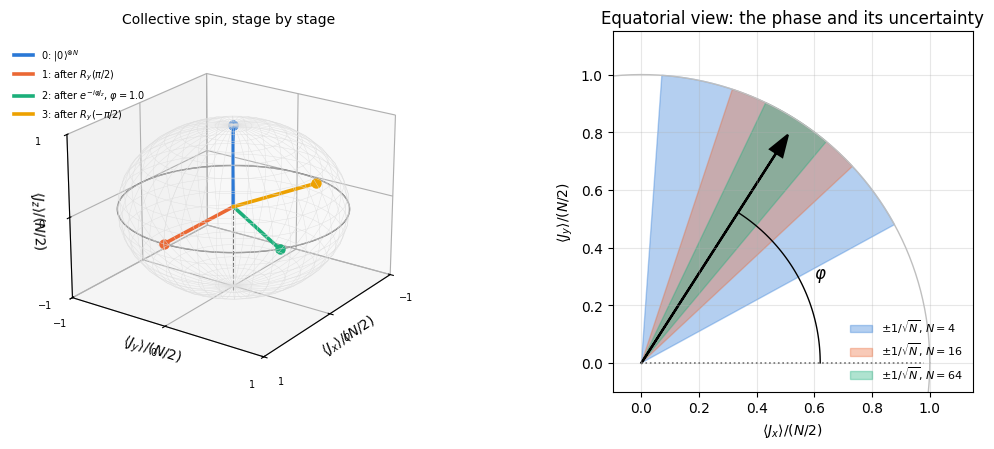

In [5]:
# ==============================================================================
# FIGURE: the collective spin during the Ramsey sequence
# ==============================================================================
from mpl_toolkits.mplot3d import Axes3D            # noqa: F401  (registers the 3d projection)


def spin_stages(N, phi):
    """Normalised mean spin <J>/(N/2) and transverse uncertainty after each stage of the protocol.

    MATH   stage 0: |0>^N        -> (0, 0, 1)
           stage 1: Ry(+pi/2)    -> (1, 0, 0)                    the coherent spin state
           stage 2: Rz(phi)      -> (cos phi, sin phi, 0)        the phase is now an azimuthal angle
           stage 3: Ry(-pi/2)    -> (0, sin phi, cos phi)        the z component IS the signal
    IMPLEMENTATION  the covariance of a coherent spin state has eigenvalues (0, N/4, N/4): it is EXACTLY
           sharp along its own mean direction and equally fuzzy in the two transverse ones.  So summing
           the two SMALLEST eigenvalues picks up 0 + N/4 and returns the transverse width
           Delta J_perp = sqrt(N)/2, i.e. sqrt(N/4)/(N/2) = 1/sqrt(N) after normalisation.  The recipe
           relies on that exact zero and would have to be replaced (project onto the plane orthogonal
           to <J>) for a state whose spin length is not maximal.
    """
    vecs, widths = [], []
    psi = zero_state(N)
    for U in (None, ry(jnp.pi / 2), rz(phi), ry(-jnp.pi / 2)):
        if U is not None:
            psi = collective_pulse(psi, U)
        mean, cov = spin_moments(psi)
        n = np.asarray(mean) / (N / 2)
        # transverse spread: smallest two eigenvalues of the covariance, in units of the spin length
        w = np.sqrt(np.sort(np.linalg.eigvalsh(np.asarray(cov)))[:2].sum()) / (N / 2)
        vecs.append(n); widths.append(w)
    return np.array(vecs), np.array(widths)


N_BS, PHI_BS = 16, 1.0
stages, widths = spin_stages(N_BS, PHI_BS)
labels = [r"0: $\vert 0\rangle^{\otimes N}$", r"1: after $R_y(\pi/2)$",
          rf"2: after $e^{{-i\varphi J_z}}$, $\varphi={PHI_BS}$", r"3: after $R_y(-\pi/2)$"]
print(f"N = {N_BS}, phi = {PHI_BS}:  normalised mean spin at each stage")
for lab, v, w in zip(["|0>^N", "after Ry(+pi/2)", "after Rz(phi)", "after Ry(-pi/2)"], stages, widths):
    print(f"  {lab:>18s}  <J>/(N/2) = ({v[0]:+.6f}, {v[1]:+.6f}, {v[2]:+.6f})   "
          f"transverse width = {w:.6f}   1/sqrt(N) = {1 / np.sqrt(N_BS):.6f}")

fig = plt.figure(figsize=(11.5, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
u, v = np.mgrid[0:2 * np.pi:41j, 0:np.pi:21j]
ax.plot_wireframe(np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v), color="0.87", lw=0.3)
circ = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(circ), np.sin(circ), 0 * circ, color="0.45", lw=1.0)            # equator
ax.plot([0, 0], [0, 0], [-1.05, 1.05], color="0.45", lw=0.8, ls="--")          # z axis
for i, (vec, lab) in enumerate(zip(stages, labels)):
    ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color=PALETTE[i], lw=2.6, label=lab)
    ax.scatter([vec[0]], [vec[1]], [vec[2]], color=PALETTE[i], s=42, depthshade=False)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_xlabel(r"$\langle J_x\rangle/(N/2)$", labelpad=-8)
ax.set_ylabel(r"$\langle J_y\rangle/(N/2)$", labelpad=-8)
ax.set_zlabel(r"$\langle J_z\rangle/(N/2)$", labelpad=-8)
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1]); ax.set_zticks([-1, 0, 1])
ax.tick_params(labelsize=7)
ax.view_init(elev=22, azim=35)
ax.set_title("Collective spin, stage by stage", fontsize=10)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(-0.12, 0.98))

ax2 = fig.add_subplot(1, 2, 2)
th = np.linspace(0, 2 * np.pi, 400)
ax2.plot(np.cos(th), np.sin(th), color="0.75", lw=1.0)
for i, N in enumerate((4, 16, 64)):
    w = 1 / np.sqrt(N)
    a = np.linspace(PHI_BS - w, PHI_BS + w, 60)
    ax2.fill(np.concatenate([[0], np.cos(a)]), np.concatenate([[0], np.sin(a)]),
             color=PALETTE[i], alpha=0.35, label=rf"$\pm1/\sqrt{{N}}$, $N={N}$")
ax2.arrow(0, 0, np.cos(PHI_BS) * 0.94, np.sin(PHI_BS) * 0.94, color="k", lw=1.6,
          head_width=0.05, length_includes_head=True)
ax2.plot([0, 0.98], [0, 0], color="0.45", lw=1.2, ls=":")
arc = np.linspace(0, PHI_BS, 60)
ax2.plot(0.62 * np.cos(arc), 0.62 * np.sin(arc), color="k", lw=1.0)
ax2.text(0.68 * np.cos(PHI_BS / 2), 0.68 * np.sin(PHI_BS / 2) - 0.03, r"$\varphi$", fontsize=12)
ax2.set_aspect("equal"); ax2.set_xlim(-0.1, 1.15); ax2.set_ylim(-0.1, 1.15)
ax2.set_xlabel(r"$\langle J_x\rangle/(N/2)$"); ax2.set_ylabel(r"$\langle J_y\rangle/(N/2)$")
ax2.set_title(r"Equatorial view: the phase and its uncertainty")
ax2.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

**Left.** The arrow starts at the north pole, is tipped onto the equator along $+x$ by the first pulse, rotates in the
equatorial plane by $\varphi$, and is brought back towards the $z$ axis by the second pulse, where its $z$ component is the
signal $\cos\varphi$ that the atom counter reads.

**Right.** Looking down the $z$ axis at the interrogation stage. The phase $\varphi$ is the angle of the arrow, and the
shaded wedges are its uncertainty $1/\sqrt N$: the angular resolution of the interferometer is set by how narrow that wedge
is. Quadrupling the atom number halves it, which is the standard quantum limit read off the geometry. Beating it requires making the
patch at the tip of the arrow *non-circular*, squeezed in the azimuthal direction
([notebook 33](./33_spin_squeezing_one_axis_twisting.ipynb)), or abandoning the picture of a long arrow altogether
([notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb)).

## 6. Projection noise and error propagation

### 6.1 The noise

At the end of the sequence each atom is an independent coin with $P(\text{excited})=p(\varphi)$, so

$$\mathrm{Var}(n_1)=Np(1-p),\qquad
\mathrm{Var}(J_z)=\mathrm{Var}\!\left(\frac N2-n_1\right)=Np(1-p)=\frac N4\sin^2\varphi, \tag{8}$$

using $p(1-p)=\tfrac{1-\cos\varphi}{2}\cdot\tfrac{1+\cos\varphi}{2}=\tfrac14\sin^2\varphi$. This is **quantum projection
noise** (Itano and co-workers, 1993): the randomness of projecting $N$ independent superpositions onto the measurement
basis, present even with a noiseless apparatus and a perfect detector. On the Bloch sphere it is the fuzzy patch at the tip of
the arrow, of angular radius $\sim1/\sqrt N$.

### 6.2 Error propagation

The experimenter measures $J_z$ and inverts the signal (7). For a single repetition, linear error propagation gives

$$\Delta\varphi=\frac{\Delta J_z}{\left\vert\partial\langle J_z\rangle/\partial\varphi\right\vert}
=\frac{\tfrac{\sqrt N}{2}\vert\sin\varphi\vert}{\tfrac N2\vert\sin\varphi\vert}=\frac{1}{\sqrt N}. \tag{9}$$

Averaging $M$ independent repetitions divides the variance by $M$:

$$\boxed{\ \Delta\varphi=\frac{1}{\sqrt{NM}}\ }\qquad\textbf{the standard quantum limit.} \tag{10}$$

Two consequences, both tested numerically below.

**(a) The $\varphi$-dependence cancels — but only for perfect contrast.** In (9) the factor $\vert\sin\varphi\vert$ appears in
the numerator *and* the denominator. Real interferometers have a reduced **contrast** $C\le1$, $p(\varphi)=\tfrac12(1-C\cos\varphi)$
(imperfect pulses, decoherence, imperfect detection). Then $\mathrm{Var}(J_z)=\tfrac N4(1-C^2\cos^2\varphi)$ while the slope is
$\tfrac{NC}{2}\vert\sin\varphi\vert$, so — after dividing by $\sqrt M$ for $M$ repetitions, which is the form every table and
figure below uses —

$$\Delta\varphi=\frac{1}{\sqrt{NM}}\,\frac{\sqrt{1-C^2\cos^2\varphi}}{C\,\vert\sin\varphi\vert}, \tag{11}$$

which **diverges at the fringe extrema** $\varphi=0,\pi$ whenever $C<1$ and is minimal at **mid-fringe** $\varphi=\pi/2$,
where it equals $1/(C\sqrt{NM})$. This is why clocks are operated at the half-height points of their fringe.

**(b) At perfect contrast the extrema are a $0/0$ limit, and the bound stops describing any usable estimator.** Setting
$C=1$ in (11) gives $1/\sqrt{NM}$ for every $\varphi$ in the open interval $(0,\pi)$, including the limit $\varphi\to0$.
But at $\varphi=0$ the signal is *quadratic*, $\langle J_z\rangle\simeq\tfrac N2(1-\varphi^2/2)$: there is no linear response
to propagate errors through, the estimator cannot tell $+\varphi$ from $-\varphi$, and — as Section 13 will show by measuring
it — the estimator becomes strongly biased and its distribution strongly non-Gaussian. Exactly at $\varphi=0$ the limit and
the value disagree: $\lim_{\varphi\to0^+}\Delta\varphi=1/\sqrt{NM}$, but the outcome distribution at $\varphi=0$ is
deterministic, its Fisher information is $F_C=0$, and the regularity condition of the Cramér–Rao theorem fails, so the
theorem makes no statement at that point (Section 7.1). A bound can be correct and still describe no estimator that is
used in practice.

In [6]:
# ==============================================================================
# STEP 2: projection noise -- Var(J_z) from the engine against Eq. (8)
# ==============================================================================
print(f"{'N':>4s} {'phi':>8s} {'Var(J_z) engine':>17s} {'(N/4) sin^2(phi)':>18s} {'Delta phi (Eq. 9)':>19s}")
err_var = 0.0
for N in (4, 8):
    for phi in (0.3, np.pi / 2, 2.0):
        psi = ramsey_state(N, phi)
        jz, var = jz_mean_var(psi)
        pred = N / 4 * np.sin(phi) ** 2
        err_var = max(err_var, abs(var - pred))
        dphi = np.sqrt(var) / abs(N / 2 * np.sin(phi))
        print(f"{N:4d} {phi:8.4f} {var:17.9f} {pred:18.9f} {dphi:19.9f}")
print(f"\nlargest deviation from Eq. (8): {err_var:.2e}      1/sqrt(N):  N=4 -> {1 / np.sqrt(4):.6f},  "
      f"N=8 -> {1 / np.sqrt(8):.6f}")
assert err_var < 1e3 * TOL

   N      phi   Var(J_z) engine   (N/4) sin^2(phi)   Delta phi (Eq. 9)


   4   0.3000       0.087332193        0.087332193         0.500000000
   4   1.5708       1.000000000        1.000000000         0.500000000
   4   2.0000       0.826821810        0.826821810         0.500000000


   8   0.3000       0.174664385        0.174664385         0.353553391
   8   1.5708       2.000000000        2.000000000         0.353553391
   8   2.0000       1.653643621        1.653643621         0.353553391

largest deviation from Eq. (8): 2.19e-14      1/sqrt(N):  N=4 -> 0.500000,  N=8 -> 0.353553


The engine's covariance matrix agrees with $\tfrac N4\sin^2\varphi$ to $2\cdot10^{-14}$, and the error-propagation ratio is
$1/\sqrt N$ at every phase listed, as Eq. (9) predicts: $0.5$ for $N=4$ and $0.353553$ for $N=8$.

## 7. Fisher information: atom counting is optimal

Error propagation is a heuristic — it uses only the mean and the variance of one observable. Fisher information uses the whole
outcome distribution, and it tells us whether a *better* estimator could exist.

### 7.1 Classical Fisher information of the Ramsey readout

The measurement record of one repetition is the bit string $s\in\{0,1\}^N$; the atoms are independent, so by additivity of
Fisher information over independent subsystems it suffices to compute the information of one atom and multiply by $N$. One
atom has two outcomes with $p_1=p=\sin^2(\varphi/2)$ and $p_0=1-p$, and Eq. (1) reads

$$F_1(\varphi)=\frac{(\partial_\varphi p)^2}{p}+\frac{(\partial_\varphi(1-p))^2}{1-p}
=(\partial_\varphi p)^2\left(\frac1p+\frac1{1-p}\right)=\frac{(\partial_\varphi p)^2}{p(1-p)} .$$

With $p=\tfrac12(1-\cos\varphi)$ we have $\partial_\varphi p=\tfrac12\sin\varphi$ and $p(1-p)=\tfrac14\sin^2\varphi$, so

$$F_1(\varphi)=\frac{\tfrac14\sin^2\varphi}{\tfrac14\sin^2\varphi}=1\quad\text{for }0<\varphi<\pi,
\qquad\Longrightarrow\qquad F_C(\varphi)=N\ \ \text{for }0<\varphi<\pi. \tag{12}$$

A Ramsey measurement of $N$ uncorrelated atoms therefore carries exactly **one unit of Fisher information per atom, at every
operating point strictly inside the fringe**. The Cramér–Rao bound (2) with $M$ repetitions is then
$\Delta\varphi\ge1/\sqrt{NM}$ — the same Eq. (10) as before, now as a statement about *all* (locally unbiased)
estimators, of which inverting the mean is one.

> **Common pitfall (the endpoints are not in the "every").** The cancellation in (12) is a $0/0$ limit: both $\partial_\varphi p$
> and $p(1-p)$ vanish at $\varphi=0$ and $\varphi=\pi$. At $\varphi=0$ *exactly*, $p=0$: only the outcome "no atom excited"
> has non-zero probability, and its derivative is zero, so the sum in Eq. (1) gives $F_1(0)=0$, not $1$. The same happens at
> $\varphi=\pi$. The function is therefore **discontinuous** at the two endpoints, and the Cramér–Rao theorem does not apply
> there at all: its regularity conditions require the set of outcomes with $p>0$ to be independent of the parameter, and that
> set collapses from two elements to one exactly at the extrema. In code, `cfi_binomial(0.0, N, 1.0)` evaluates $0/0$ and
> returns `nan`, which correctly signals that the formula does not apply; every scan below therefore starts at
> $\varphi=0.02$ rather than $0$.
> Section 13 measures what this costs an actual estimator.

### 7.2 Quantum Fisher information of the probe

The probe entering the free evolution is the coherent spin state $\vert+\rangle^{\otimes N}$, and the generator is $G=J_z$.
Equation (3) gives

$$F_Q=4\,\mathrm{Var}(J_z)_{\vert+\rangle^{\otimes N}}
=4\cdot\frac14\sum_q\big(\langle Z_q^2\rangle-\langle Z_q\rangle^2\big)=\sum_q(1-0)=N. \tag{13}$$

(The cross terms vanish because the atoms are uncorrelated, and $\langle Z\rangle_+=0$, $Z^2=\mathbb 1$.)

### 7.3 The conclusion

$$F_C(\varphi)=N=F_Q\qquad\text{for }0<\varphi<\pi .$$

**Counting atoms after the second $\pi/2$ pulse extracts all the phase information the coherent spin state contains.**
No other measurement, including a joint measurement of all $M$ copies, gives more Fisher information, and no locally
unbiased estimator can beat $1/\sqrt{NM}$ with this probe at an interior working point. A biased estimator can show a
smaller spread (Section 13), but not a smaller error over a range of phases. To do better at fixed $\nu=NM$ one must
change the *probe* — entangle the atoms — which is the subject of the rest of this chapter.

The value $F_Q=N$ is also exactly the boundary between classical and quantum: $F_Q>N$ for a state of $N$ qubits is a
sufficient criterion for entanglement (see notebook [29](./29_quantum_fisher_information.ipynb)). Ramsey interferometry sits
precisely on that boundary.

In [7]:
# ==============================================================================
# STEP 3: the two Fisher informations, side by side
# ==============================================================================
def cfi_binomial(phi, N, contrast=1.0):
    """Classical Fisher information of the Ramsey readout of N independent atoms with fringe contrast C.

    MATH   p(phi) = (1 - C cos phi)/2,   F = N (dp/dphi)^2 / [p(1-p)] = N C^2 sin^2 phi / (1 - C^2 cos^2 phi).
           C = 1  ->  F = N for 0 < phi < pi  [Eq. (12)];  C < 1  ->  maximal at mid-fringe (N C^2), zero at
           the extrema.
    CAUTION  at C = 1 and phi = 0 or pi the expression is 0/0 and this function returns nan.  That is not a
           numerical accident: the true value there is F = 0 (the outcome is deterministic), so the limit
           and the value differ and the Cramér–Rao regularity conditions fail.  Evaluate strictly inside
           the fringe.
    """
    c = jnp.cos(phi)
    return N * contrast ** 2 * (1 - c ** 2) / (1 - contrast ** 2 * c ** 2)


print(f"{'N':>4s} {'phi':>8s} {'F classical':>13s} {'F_Q = 4Var(J_z)':>17s} {'1/sqrt(N)':>11s}")
err_fi = 0.0
for N in (2, 4, 8, 12):
    fq = float(qfi_pure(css_state(N), Z))                  # 4 Var(J_z) of the probe |+>^N
    for phi in (0.2, np.pi / 2, 2.7):
        fc = float(cfi_binomial(phi, N))
        err_fi = max(err_fi, abs(fc - N), abs(fq - N))
        print(f"{N:4d} {phi:8.4f} {fc:13.9f} {fq:17.9f} {1 / np.sqrt(N):11.6f}")
print(f"\nlargest deviation of F and F_Q from N: {err_fi:.2e}   -> the readout saturates the quantum Cramér–Rao bound")
assert err_fi < 1e-9

   N      phi   F classical   F_Q = 4Var(J_z)   1/sqrt(N)


   2   0.2000   2.000000000       2.000000000    0.707107
   2   1.5708   2.000000000       2.000000000    0.707107
   2   2.7000   2.000000000       2.000000000    0.707107
   4   0.2000   4.000000000       4.000000000    0.500000
   4   1.5708   4.000000000       4.000000000    0.500000
   4   2.7000   4.000000000       4.000000000    0.500000
   8   0.2000   8.000000000       8.000000000    0.353553
   8   1.5708   8.000000000       8.000000000    0.353553
   8   2.7000   8.000000000       8.000000000    0.353553


  12   0.2000  12.000000000      12.000000000    0.288675
  12   1.5708  12.000000000      12.000000000    0.288675
  12   2.7000  12.000000000      12.000000000    0.288675

largest deviation of F and F_Q from N: 8.88e-16   -> the readout saturates the quantum Cramér–Rao bound


Both informations equal $N$ at every interior phase and every atom number tested. The classical Fisher information of what we
actually measure *equals* the quantum Fisher information of the state we prepared, which is the formal statement of "the
measurement is optimal". Contrast this with the last column: the achievable $\Delta\varphi$ per repetition is $1/\sqrt N$,
improving only as the square root of the atom number.

## 8. From formulas to data: sampling the measurement record

Up to here we computed expectation values — quantities a real experiment never observes directly. An experiment observes a
**record**: for each of $M$ repetitions, $N$ bits saying which atoms were found excited. Everything else (means, variances,
estimates, error bars) is *inferred* from that record. From here on we simulate the record.

The engine's `sample_bitstrings(key, psi, shots)` draws `shots` outcomes from the Born distribution $p(s)=\vert\psi[s]\vert^2$
by sampling the flat index with `jax.random.categorical` and unpacking the bits. One call gives the $M$ repetitions of one
experiment; `vmap` over a batch of keys gives many **independent experiments**, which is what we need in order to *measure*
a standard deviation rather than assume one.

> **JAX practice.** Randomness in JAX is explicit: a function that samples takes a `key`, and `jax.random.split(key, n)`
> produces $n$ independent keys deterministically. Same seed, same figure. The pattern below recurs throughout the chapter:
> one key per experiment, `vmap` over the batch of keys, `jit` around the whole thing with the shot count as a *static*
> argument (it fixes an array shape).

In [8]:
# ==============================================================================
# STEP 4: simulate K independent Ramsey experiments, each of M repetitions
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def ramsey_counts(key, phi, N, shots, n_exp):
    """Total number of excited atoms in each of `n_exp` independent experiments of `shots` repetitions.

    RETURNS int array of shape (n_exp,);  entry k in {0, ..., N*shots}.
    MATH    each repetition yields N independent bits with P(bit = 1) = sin^2(phi/2);
            the experiment reports their sum, which is Binomial(N*shots, p(phi)).
    JAX     `vmap` over the split keys = `n_exp` independent experiments in ONE compiled program;
            `N`, `shots`, `n_exp` are static (they fix shapes), `phi` is traced.
    MEMORY  careful: the categorical sampler materialises `shots` x 2^N numbers per experiment, so
            n_exp * shots * 2^N must fit in RAM -- see the note after this cell.
    """
    psi = ramsey_state(N, phi)
    keys = jax.random.split(key, n_exp)
    return jax.vmap(lambda k: jnp.sum(sample_bitstrings(k, psi, shots)))(keys)


KEY0 = jax.random.PRNGKey(20260219)         # fixed seed: this notebook is reproducible
PHI_TRUE = np.pi / 2                        # mid-fringe: the operating point of every clock

t0 = time.time()
cnt = ramsey_counts(KEY0, PHI_TRUE, 8, 100, 300).block_until_ready()
t_first = time.time() - t0
t0 = time.time()
cnt = ramsey_counts(jax.random.PRNGKey(1), PHI_TRUE, 8, 100, 300).block_until_ready()
t_run = time.time() - t0

N_, M_, K_ = 8, 100, 300
p_true = np.sin(PHI_TRUE / 2) ** 2
frac = np.asarray(cnt) / (N_ * M_)
print(f"N = {N_} atoms, M = {M_} repetitions, K = {K_} independent experiments")
print(f"compile + run: {t_first:.2f} s      run only (cached): {t_run:.3f} s")
print(f"excited fraction:  mean over experiments = {frac.mean():.6f}   expected p(phi) = {p_true:.6f}")
print(f"                   std over experiments  = {frac.std(ddof=1):.6f}   "
      f"expected sqrt(p(1-p)/(N M)) = {np.sqrt(p_true * (1 - p_true) / (N_ * M_)):.6f}")
assert abs(frac.mean() - p_true) < 5 * np.sqrt(p_true * (1 - p_true) / (N_ * M_ * K_))

N = 8 atoms, M = 100 repetitions, K = 300 independent experiments
compile + run: 0.45 s      run only (cached): 0.081 s
excited fraction:  mean over experiments = 0.499717   expected p(phi) = 0.500000
                   std over experiments  = 0.017768   expected sqrt(p(1-p)/(N M)) = 0.017678


The sampled excited fraction agrees with $p(\pi/2)=1/2$ and its spread agrees with the binomial prediction
$\sqrt{p(1-p)/(NM)}$ within the $4\%$ statistical precision of $K=300$ experiments, so the spread, and not only the mean,
has the binomial value. Section 9 makes this test sharper.

> **Common pitfall (memory).** `jax.random.categorical` works by adding Gumbel noise to the **full** vector of $2^N$
> log-probabilities and taking an `argmax`, so one call with `shots` samples temporarily allocates `shots` $\times\,2^N$
> floating-point numbers. Under a `vmap` over $K$ experiments that becomes $K\cdot M\cdot 2^N$ — for $K=400$, $M=200$,
> $N=12$ this is $3\cdot10^8$ doubles, i.e. gigabytes. Two ways out: process the experiments in chunks, or exploit a
> structure of the state. We do the latter — but only after *verifying* it numerically in the next cell.

## 9. A cheaper, exactly equivalent sampler

We proved in Section 5.3 (and verified via the Schmidt values in Section 5) that the state at readout is the product
$(c_0\vert0\rangle+c_1\vert1\rangle)^{\otimes N}$. Therefore the $N$ bits of one repetition are **independent Bernoulli
variables** with the same $p(\varphi)$, and sampling $N\cdot M$ coins is *exactly* the same statistical experiment as
sampling from the $2^N$-dimensional Born distribution — at cost $O(NM)$ instead of $O(M2^N)$.

The equivalence is an exact consequence of the product structure, with no numerical approximation involved. It is
nevertheless a claim about code, and the cell below tests it.

**Designing a test that can fail.** The claim being made has two halves: the atoms have the right *marginal* probability
$p(\varphi)$, and they are *independent*. A two-sample comparison of the mean count tests only the first half — the mean of
the total count is $NMp$ whether the $N$ bits of a repetition are independent or perfectly correlated. The second half
shows up in the **variance**: independent atoms give $\mathrm{Var}(k)=NMp(1-p)$, whereas $N$ atoms locked together would
give $N^2Mp(1-p)$, a factor $N$ larger. The cell below therefore runs a two-sample $z$-test on the mean *and* on the
variance, and, to show that the second one detects correlations, feeds the same test a deliberately **wrong**
sampler in which all $N$ atoms of a repetition report the same bit. That control has exactly the right mean and must fail
the variance test.

> **Numerical practice.** A checkpoint that cannot fail for the error it is supposed to catch verifies nothing. Before
> writing an `assert`, name the wrong implementation you are guarding against and check that the statistic responds to
> it; if it is cheap, run the wrong version and show the test firing.

In [9]:
# ==============================================================================
# STEP 5: independent-coin sampler, and the check that it matches the engine sampler
# ==============================================================================
@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def ramsey_counts_fast(key, phi, N, shots, n_exp, contrast=1.0):
    """Same output as `ramsey_counts`, sampling the N*shots independent atoms directly.

    MATH   p(phi) = (1 - C cos phi)/2  -- Eq. (6) with contrast C (C = 1 is the ideal protocol).
    WHY exact: the readout state is a PRODUCT state, so the atoms are statistically independent.
    COST   O(n_exp * shots * N) random numbers, vs O(n_exp * shots * 2^N) for the categorical sampler.
    """
    p = (1 - contrast * jnp.cos(phi)) / 2
    bits = jax.random.bernoulli(key, p, (n_exp, shots, N))
    return jnp.sum(bits, axis=(1, 2))


@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def ramsey_counts_wrong(key, phi, N, shots, n_exp):
    """DELIBERATELY WRONG control sampler: the N atoms of a repetition all report the SAME bit.

    Same marginal p(phi) per atom, hence the SAME mean count N*shots*p, but Var(k) is N times too large.
    It exists only to show that the checkpoint below can fail -- never use it for physics.
    """
    p = (1 - jnp.cos(phi)) / 2
    return N * jnp.sum(jax.random.bernoulli(key, p, (n_exp, shots)), axis=1)


def two_sample_z(a, b):
    """(z of the mean difference, z of the log variance ratio) for two independent samples.

    MATH  mean:  z = (<a> - <b>) / sqrt(Var(a)/n_a + Var(b)/n_b)
          var :  z = ln(s_a^2/s_b^2) / sqrt(SE_a^2 + SE_b^2),  SE^2 = (mu_4/s^4 - 1)/n
                 (delta method for ln s^2; the kurtosis mu_4/s^4 is estimated from the sample, so the
                  test does NOT assume Gaussian data -- counts here are binomial.)
    """
    def se2(v):
        n = len(v); s2 = v.var(ddof=1)
        return (((v - v.mean()) ** 4).mean() / s2 ** 2 - 1) / n
    z_mean = (a.mean() - b.mean()) / np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    z_var = np.log(a.var(ddof=1) / b.var(ddof=1)) / np.sqrt(se2(a) + se2(b))
    return float(z_mean), float(z_var)


# --- CHECKPOINT: the two samplers produce statistically indistinguishable data ------------------------
#     ... and the same test REJECTS a wrong sampler with the same mean but correlated atoms.
K_CHK, M_CHK = 2000, 20
print(f"{'N':>4s} {'phi':>7s} {'mean (engine)':>14s} {'mean (coins)':>13s} {'std (engine)':>13s} "
      f"{'std (coins)':>12s} {'z mean':>9s} {'z var':>9s} {'z var vs WRONG':>16s}")
z_wrong_worst = 0.0
for N in (4, 6, 8):
    for phi in (0.7, np.pi / 2):
        ka, kb, kc = jax.random.split(jax.random.PRNGKey(7 * N + int(10 * phi)), 3)
        a = np.asarray(ramsey_counts(ka, phi, N, M_CHK, K_CHK), float)
        b = np.asarray(ramsey_counts_fast(kb, phi, N, M_CHK, K_CHK), float)
        w = np.asarray(ramsey_counts_wrong(kc, phi, N, M_CHK, K_CHK), float)
        z_m, z_v = two_sample_z(a, b)
        z_mw, z_vw = two_sample_z(a, w)
        z_wrong_worst = max(z_wrong_worst, abs(z_mw))
        print(f"{N:4d} {phi:7.4f} {a.mean():14.4f} {b.mean():13.4f} {a.std(ddof=1):13.4f} "
              f"{b.std(ddof=1):12.4f} {z_m:9.3f} {z_v:9.3f} {z_vw:16.1f}")
        assert abs(z_m) < 4.0, "the coin sampler has the wrong marginal probability"
        assert abs(z_v) < 4.0, "the coin sampler has the wrong count variance"
        assert abs(z_vw) > 10.0, "the variance test failed to reject the correlated-atom sampler"
print(f"\nworst |z| of the MEAN test against the wrong sampler: {z_wrong_worst:.2f}  "
      f"(it passes -- the mean carries no information about independence)")

   N     phi  mean (engine)  mean (coins)  std (engine)  std (coins)    z mean     z var   z var vs WRONG


   4  0.7000         9.3630        9.4435        2.8636       3.0007    -0.868    -2.029            -30.5
   4  1.5708        40.2165       40.1630        4.4823       4.4207     0.380     0.606            -31.5


   6  0.7000        14.0965       14.0320        3.5462       3.5309     0.576     0.198            -36.7
   6  1.5708        60.2910       60.1025        5.3484       5.3836     1.111    -0.296            -41.2


   8  0.7000        18.8505       18.8140        4.0549       3.9825     0.287     0.809            -47.1
   8  1.5708        79.9885       80.0115        6.2970       6.2725    -0.116     0.173            -46.9

worst |z| of the MEAN test against the wrong sampler: 1.24  (it passes -- the mean carries no information about independence)


Every $z$-score of the engine-versus-coins comparison — of the mean *and* of the variance — is well inside $\pm4$, and the standard
deviations agree to the third digit. The coin sampler is the engine sampler for this state, and we may use it for the large
sweeps without losing any physics.

The last two columns are the reason to trust that conclusion. The wrong sampler, whose $N$ atoms are locked together, passes
the mean test (the worst $\vert z\vert$ over the six cases is printed above) and is rejected by the variance test at
$\vert z\vert\simeq30$–$50$. Had the checkpoint compared means only, it would have certified a sampler that gets the physics
of projection noise completely wrong, and the property the coin sampler relies on is precisely the *independence* of the
atoms. (For an entangled probe the coin sampler would be wrong in just this
way — see [notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb), where the $N$ bits of a GHZ record are maximally
correlated, exactly like the control sampler above.)

## 10. Two estimators

### 10.1 Method of moments

Invert the signal. From $M$ repetitions we have $k=\sum n_1$, the total number of excitation events out of $NM$ atom
detections, hence the empirical probability $\hat p=k/(NM)$. Equation (6) inverted gives

$$\hat\varphi_{\mathrm{MoM}}=\arccos\big(1-2\hat p\big)
\qquad\text{(for contrast }C:\ \hat\varphi=\arccos\big[(1-2\hat p)/C\big]\text{)}. \tag{14}$$

Because $\arccos$ has domain $[-1,1]$ we must clip $\hat p$ to $[0,1]$; that clipping is harmless at mid-fringe and is exactly
the source of the bias near the fringe extrema (Section 13).

### 10.2 Maximum likelihood

The probability of observing the whole record is a product of Bernoulli factors, so the log-likelihood depends on the data
only through the count $k$:

$$\ln L(\varphi)=k\ln p(\varphi)+(NM-k)\ln\big(1-p(\varphi)\big). \tag{15}$$

Setting $\partial_\varphi\ln L=0$ and using $\partial_\varphi p\ne0$:

$$\left(\frac{k}{p}-\frac{NM-k}{1-p}\right)\partial_\varphi p=0
\ \Longrightarrow\ k(1-p)=(NM-k)p\ \Longrightarrow\ p(\hat\varphi)=\frac{k}{NM}=\hat p .$$

**The maximum-likelihood estimator coincides exactly with the method of moments here**, because $k$ is a *sufficient
statistic* for $\varphi$: the record contains no information beyond the total count. Computing the MLE numerically
therefore adds no precision. What it adds is machinery that generalises: the likelihood curve shows us the *shape* of our knowledge, including the two-fold
ambiguity $\varphi\leftrightarrow-\varphi$, and the same code will work in situations (unknown contrast, several parameters,
[notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb)) where no closed form exists.

We implement the MLE as a grid search over $\varphi\in[0,\pi]$ — trivially `vmap`-able, robust, and immune to the local
maxima that trip up gradient methods on periodic likelihoods.

In [10]:
# ==============================================================================
# STEP 6: the two estimators
# ==============================================================================
def phi_hat_mom(k, N, shots, contrast=1.0):
    """Method-of-moments phase estimate, Eq. (14).   k = total number of excited-atom detections."""
    p_hat = k / (N * shots)
    return jnp.arccos(jnp.clip((1 - 2 * p_hat) / contrast, -1.0, 1.0))


def log_likelihood(phi, k, n_atoms_total, contrast=1.0):
    """ln L(phi) of Eq. (15) for a total of `n_atoms_total` = N*M atom detections, k of them excited.
    Probabilities are clipped away from 0 and 1 so that the logarithm never overflows."""
    p = jnp.clip((1 - contrast * jnp.cos(phi)) / 2, 1e-12, 1 - 1e-12)
    return k * jnp.log(p) + (n_atoms_total - k) * jnp.log(1 - p)


PHI_GRID = jnp.linspace(0.0, jnp.pi, 4001)          # 4001 points -> grid resolution pi/4000 = 7.9e-4 rad


@partial(jax.jit, static_argnames=("n_atoms_total",))
def phi_hat_mle(k, n_atoms_total, contrast=1.0):
    """Maximum-likelihood estimate by exhaustive search on PHI_GRID (vectorised over the grid).
    JAX  `k` may be a batch: vmap the whole function over the experiments."""
    ll = jax.vmap(lambda ph: log_likelihood(ph, k, n_atoms_total, contrast))(PHI_GRID)
    return PHI_GRID[jnp.argmax(ll)]


# --- CHECKPOINT: MLE == method of moments, up to the grid spacing ------------------------------------
k_demo = np.asarray(cnt[:8])
mom = np.asarray(phi_hat_mom(jnp.asarray(k_demo), N_, M_))
mle = np.asarray([float(phi_hat_mle(int(k), n_atoms_total=N_ * M_)) for k in k_demo])
print(f"{'k':>7s} {'phi_MoM':>10s} {'phi_MLE':>10s} {'difference':>12s}")
for kk, a, b in zip(k_demo, mom, mle):
    print(f"{int(kk):7d} {a:10.6f} {b:10.6f} {a - b:12.2e}")
grid_step = float(PHI_GRID[1] - PHI_GRID[0])
print(f"\ngrid spacing = {grid_step:.2e} rad; largest |MoM - MLE| = {np.max(np.abs(mom - mle)):.2e}")
assert np.max(np.abs(mom - mle)) < grid_step

      k    phi_MoM    phi_MLE   difference
    376   1.510760   1.511106    -3.46e-04
    382   1.525781   1.526029    -2.48e-04
    411   1.598300   1.598285     1.45e-05
    416   1.610807   1.610852    -4.46e-05
    379   1.518272   1.518175     9.75e-05
    424   1.630832   1.630487     3.46e-04
    388   1.540792   1.540951    -1.59e-04
    409   1.593298   1.593573    -2.75e-04

grid spacing = 7.85e-04 rad; largest |MoM - MLE| = 3.46e-04


The two estimators agree to better than one grid step, confirming the sufficiency argument analytically *and* numerically.
From now on we use the closed form (14), which is `vmap`-friendly and free.

## 11. The distribution of the estimate

The experimental question is how much the answers scatter when the experiment is repeated. We run $K$ independent
experiments at mid-fringe, histogram $\hat\varphi$, and compare with the Gaussian of width
$1/\sqrt{NM}$ predicted by the Cramér–Rao bound. We also measure the **bias** $\mathbb E[\hat\varphi]-\varphi_{\mathrm{true}}$
and quote its own error bar $\Delta\varphi/\sqrt K$ — a bias is only meaningful if it is larger than the uncertainty with
which it was measured.

In [11]:
# ==============================================================================
# STEP 7: K independent experiments at mid-fringe -- histogram, bias, measured Delta phi
# ==============================================================================
N_HIST, M_HIST, K_HIST = 8, 100, 12000
k_hist = ramsey_counts_fast(jax.random.PRNGKey(101), PHI_TRUE, N_HIST, M_HIST, K_HIST)
phi_hist = np.asarray(phi_hat_mom(k_hist, N_HIST, M_HIST))

crb = 1.0 / np.sqrt(N_HIST * M_HIST)
bias = phi_hist.mean() - PHI_TRUE
sigma = phi_hist.std(ddof=1)
print(f"N = {N_HIST}, M = {M_HIST}, K = {K_HIST} experiments, phi_true = {PHI_TRUE:.6f} (mid-fringe)")
print(f"  mean estimate        = {phi_hist.mean():.6f}")
print(f"  bias                 = {bias:+.2e}   +- {sigma / np.sqrt(K_HIST):.2e}  (statistical error of the mean)")
print(f"  measured Delta phi   = {sigma:.6f}  +- {std_of_std(sigma, K_HIST):.6f}")
print(f"  Cramér–Rao 1/sqrt(NM)= {crb:.6f}")
print(f"  ratio measured / CRB = {sigma / crb:.4f}")
assert abs(bias) < 5 * sigma / np.sqrt(K_HIST) + 1e-3
assert 0.9 < sigma / crb < 1.15

N = 8, M = 100, K = 12000 experiments, phi_true = 1.570796 (mid-fringe)
  mean estimate        = 1.571254
  bias                 = +4.58e-04   +- 3.24e-04  (statistical error of the mean)
  measured Delta phi   = 0.035499  +- 0.000229
  Cramér–Rao 1/sqrt(NM)= 0.035355
  ratio measured / CRB = 1.0041


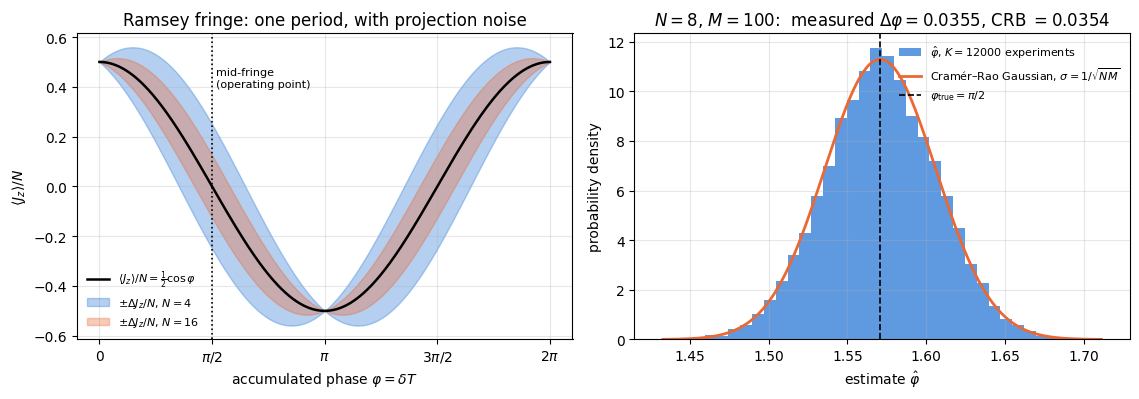

In [12]:
# ==============================================================================
# FIGURE 1: the Ramsey fringe with projection noise, and the histogram of estimates
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

ph = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(ph, np.cos(ph) / 2, color="k", lw=1.8,
             label=r"$\langle J_z\rangle/N=\frac{1}{2}\cos\varphi$")
for i, N in enumerate((4, 16)):
    sig = N / 2 * np.cos(ph)
    noise = np.sqrt(N / 4 * np.sin(ph) ** 2)
    axes[0].fill_between(ph, (sig - noise) / N, (sig + noise) / N, color=PALETTE[i], alpha=0.35,
                         label=rf"$\pm\Delta J_z/N$, $N={N}$")
axes[0].axvline(np.pi / 2, color="k", ls=":", lw=1.2)
axes[0].text(np.pi / 2 + 0.06, 0.40, "mid-fringe\n(operating point)", fontsize=8)
axes[0].set_xlabel(r"accumulated phase $\varphi=\delta T$")
axes[0].set_ylabel(r"$\langle J_z\rangle/N$")
axes[0].set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
axes[0].set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axes[0].set_title("Ramsey fringe: one period, with projection noise")
axes[0].legend(fontsize=8, loc="lower left")

# the estimate is a function of the INTEGER count k, so it takes only discrete values: put the bin edges
# half-way between consecutive attainable values (three per bin) instead of using an arbitrary bin width
k_edges = np.arange(int(k_hist.min()) - 1, int(k_hist.max()) + 3, 3) - 0.5
edges = np.asarray(phi_hat_mom(jnp.asarray(k_edges, dtype=RDTYPE), N_HIST, M_HIST))
axes[1].hist(phi_hist, bins=edges, density=True, color=PALETTE[0], alpha=0.75,
             label=rf"$\hat\varphi$, $K={K_HIST}$ experiments")
xx = np.linspace(phi_hist.min(), phi_hist.max(), 300)
axes[1].plot(xx, np.exp(-(xx - PHI_TRUE) ** 2 / (2 * crb ** 2)) / np.sqrt(2 * np.pi * crb ** 2),
             color=PALETTE[1], lw=2.0, label=r"Cramér–Rao Gaussian, $\sigma=1/\sqrt{NM}$")
axes[1].axvline(PHI_TRUE, color="k", ls="--", lw=1.2, label=r"$\varphi_{\mathrm{true}}=\pi/2$")
axes[1].set_xlabel(r"estimate $\hat\varphi$"); axes[1].set_ylabel("probability density")
axes[1].set_title(rf"$N={N_HIST}$, $M={M_HIST}$:  measured $\Delta\varphi={sigma:.4f}$, CRB $={crb:.4f}$")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Left.** The relative signal $\langle J_z\rangle/N$ is the same cosine for every $N$; what changes is the width of the noise
band, which shrinks as $1/\sqrt N$ (the $N=16$ band is half as wide as the $N=4$ band). The band closes at the extrema
$\varphi=0,\pi$ — there the outcome is nearly deterministic — and is widest at mid-fringe, where the *slope* is also largest.
The competition between the two is exactly the cancellation of Eq. (9).

**Right.** Twelve thousand simulated experiments at $N=8$, $M=100$. The histogram is a clean Gaussian centred on
$\varphi_{\mathrm{true}}=\pi/2$; compare the measured standard deviation printed above with the Cramér–Rao value
$1/\sqrt{800}=0.035355$, and the measured bias with its own statistical error. The bias vanishes *exactly* at mid-fringe,
and the argument is one line: at $\varphi=\pi/2$ the count $k$ is $\mathrm{Binomial}(NM,\tfrac12)$, so $u=1-2k/(NM)$ is
symmetrically distributed about $0$; and $\arccos$ satisfies $\arccos(u)+\arccos(-u)=\pi$ identically, so pairing $u$ with
$-u$ gives $\mathbb E[\hat\varphi]=\pi/2$ with no approximation. (Expanding $\hat\varphi=\pi/2-u-u^3/6-\dots$ and removing
the odd moments one by one gives the same answer.) The measured bias printed above is therefore pure sampling noise, and
it is consistent with zero; a measurement of the bias has to be made away from $\pi/2$ (Section 11.1).

The estimator is unbiased at mid-fringe, but it does not saturate the bound exactly at finite $NM$. Expanding
$\mathrm{Var}(\hat\varphi)=\mathrm{Var}(u+u^3/6+\dots)=\sigma_u^2(1+\sigma_u^2+\dots)$ with $\sigma_u^2=1/(NM)$ gives a
standard deviation $\sqrt{1+1/(NM)}\approx1+1/(2NM)=1.000625$ times the bound at $N=8$, $M=100$ (the exact binomial sum
gives $1.000626$). That is one tenth of the statistical error $0.0065$ on the printed ratio, so the simulation cannot
resolve it.

### 11.1 The bias away from mid-fringe

Away from $\varphi=\pi/2$ the symmetry is gone, and the curvature of $\arccos$ produces a bias at finite $NM$. Its size
follows from a second-order Taylor expansion (the delta method of notebook 29, Section 4.8) of
$g(\hat p)=\arccos\big[(1-2\hat p)/C\big]$ around $p$, with $\mathbb E[\hat p-p]=0$ and $\mathrm{Var}(\hat p)=p(1-p)/(NM)$.
Writing $x=(1-2p)/C=\cos\varphi$, we have $dx/dp=-2/C$ and $d^2\arccos x/dx^2=-x/(1-x^2)^{3/2}$, so
$g''(p)=-4\cos\varphi/(C^2\sin^3\varphi)$; with $p(1-p)=\tfrac14(1-C^2\cos^2\varphi)$,

$$\mathbb E[\hat\varphi]-\varphi\ \approx\ \tfrac12\,g''(p)\,\frac{p(1-p)}{NM}
=-\frac{\cos\varphi\,\big(1-C^2\cos^2\varphi\big)}{2NM\,C^2\sin^3\varphi}
\ \xrightarrow{\ C=1\ }\ -\frac{\cot\varphi}{2NM}. \tag{14a}$$

This is Eq. (36) of notebook 29 with the $M$ single-atom repetitions there replaced by the $NM$ atom detections here. It
vanishes at $\varphi=\pi/2$, as the symmetry argument requires; at $C=1$ it is negative for $\varphi<\pi/2$ and positive
for $\varphi>\pi/2$, so it pushes the estimate away from mid-fringe towards the nearer fringe extremum; and it falls like $1/(NM)$, faster than the spread $1/\sqrt{NM}$, so that the ratio bias/spread decays like $1/\sqrt{NM}$.
The same expansion to first order reproduces the variance of Eq. (11).

Because $\hat\varphi$ is a function of the single binomial count $k$, its mean and variance can also be computed
**exactly**, by summing over the $NM+1$ possible counts. The cell below measures the bias at $\varphi=\pi/4$, where
Eq. (14a) gives $NM\cdot\mathrm{bias}\to-\tfrac12$, compares the sampled numbers (with standard errors) with the exact sums,
and runs a wrong control: the hypothesis "the estimator is unbiased" must be rejected by the same data.

In [13]:
# ==============================================================================
# STEP 7b: the bias at phi = pi/4 -- sampled, exact, and Eq. (14a)
# ==============================================================================
def mom_moments_exact(phi, N, shots, contrast=1.0):
    """EXACT mean and variance of the estimator (14), summed over all NM+1 possible counts.

    MATH   k ~ Binomial(n, p),  n = N*shots,  p = (1 - C cos phi)/2,
           phi_hat(k) = arccos(clip((1 - 2k/n)/C, -1, 1)),
           E[phi_hat]   = sum_k P(k) phi_hat(k),   Var = sum_k P(k) phi_hat(k)^2 - E[phi_hat]^2.
    IMPLEMENTATION  the binomial pmf through log-gamma, so n = 600 causes no overflow.
    COST   O(N*shots) per phase -- no Monte Carlo, hence no statistical error of its own.
    """
    n = N * shots
    k = jnp.arange(n + 1, dtype=RDTYPE)
    p = jnp.clip((1 - contrast * jnp.cos(phi)) / 2, 1e-15, 1 - 1e-15)
    logP = (gammaln(n + 1.0) - gammaln(k + 1.0) - gammaln(n - k + 1.0)
            + k * jnp.log(p) + (n - k) * jnp.log1p(-p))
    P = jnp.exp(logP)
    est = jnp.arccos(jnp.clip((1 - 2 * k / n) / contrast, -1.0, 1.0))
    m1 = jnp.sum(P * est)
    return m1, jnp.clip(jnp.sum(P * est ** 2) - m1 ** 2, 0.0, None)



PHI_B, N_B, K_B = np.pi / 4, 4, 40000
print(f"phi = pi/4, N = {N_B}, K = {K_B} experiments per row;  Eq. (14a): NM * bias -> -cot(phi)/2 = "
      f"{-0.5 / np.tan(PHI_B):+.4f}\n")
print(f"{'M':>5s} {'bias sampled':>13s} {'+- SE':>9s} {'bias exact':>12s} {'Eq. (14a)':>11s} {'NM*bias exact':>14s} "
      f"{'z(samp-exact)':>14s} {'sd sampled':>11s} {'sd exact':>10s} {'z(bias = 0)':>12s}")
z_null = {}
for M in (10, 25, 100):
    nm = N_B * M
    k = ramsey_counts_fast(jax.random.fold_in(jax.random.PRNGKey(303), M), PHI_B, N_B, M, K_B)
    est = np.asarray(phi_hat_mom(k, N_B, M))
    b_s, sd_s = est.mean() - PHI_B, est.std(ddof=1)
    se = sd_s / np.sqrt(K_B)
    m_x, v_x = mom_moments_exact(PHI_B, N_B, M)
    b_x, sd_x = float(m_x) - PHI_B, float(jnp.sqrt(v_x))
    b_d = -1.0 / (2 * nm * np.tan(PHI_B))
    z_ex = (b_s - b_x) / se
    z_null[M] = b_s / se                                     # WRONG CONTROL: "the bias is zero"
    print(f"{M:5d} {b_s:+13.5f} {se:9.5f} {b_x:+12.5f} {b_d:+11.5f} {nm * b_x:+14.4f} {z_ex:+14.2f} "
          f"{sd_s:11.5f} {sd_x:10.5f} {z_null[M]:+12.1f}")
    assert abs(z_ex) < 4, "sampled bias disagrees with the exact binomial sum"
    assert abs(sd_s - sd_x) < 4 * float(std_of_std(sd_x, K_B)), "sampled spread disagrees with the exact sum"
    if M == 100:
        assert abs(nm * b_x / (-0.5 / np.tan(PHI_B)) - 1) < 0.02, "exact bias does not approach Eq. (14a)"
print(f"\nwrong control 'bias = 0' rejected at {abs(z_null[10]):.1f} and {abs(z_null[25]):.1f} standard errors "
      f"(M = 10, 25)")
assert abs(z_null[10]) > 5 and abs(z_null[25]) > 5
m_mid, _ = mom_moments_exact(np.pi / 2, N_B, 100)
print(f"exact bias at mid-fringe, same N and M = 100: {float(m_mid) - np.pi / 2:+.1e}   (zero by symmetry)")
assert abs(float(m_mid) - np.pi / 2) < 1e-10

phi = pi/4, N = 4, K = 40000 experiments per row;  Eq. (14a): NM * bias -> -cot(phi)/2 = -0.5000

    M  bias sampled     +- SE   bias exact   Eq. (14a)  NM*bias exact  z(samp-exact)  sd sampled   sd exact  z(bias = 0)


   10      -0.01482   0.00083     -0.01407    -0.01250        -0.5629          -0.90     0.16544    0.16540        -17.9


   25      -0.00627   0.00051     -0.00518    -0.00500        -0.5184          -2.15     0.10150    0.10136        -12.4


  100      -0.00147   0.00025     -0.00126    -0.00125        -0.5043          -0.85     0.05013    0.05016         -5.9

wrong control 'bias = 0' rejected at 17.9 and 12.4 standard errors (M = 10, 25)
exact bias at mid-fringe, same N and M = 100: -1.8e-13   (zero by symmetry)


The sampled bias agrees with the exact binomial sum in every row, within about two standard errors (largest
deviation $2.2$, at $M=25$), and the hypothesis
of an unbiased estimator is rejected by many standard errors at $M=10$ and $M=25$. The exact $NM\cdot\mathrm{bias}$ is
$-0.563$, $-0.518$ and $-0.504$ for $NM=40$, $100$, $400$, approaching the $-\tfrac12$ of Eq. (14a) with a correction
of order $1/(NM)$. At $M=100$ the bias, $-1.3\cdot10^{-3}$ rad, is $2.5\%$ of the spread $0.050$: it is real, and it
is negligible next to the projection noise. At mid-fringe the exact sum gives zero to rounding. Section 13 follows the
bias to the fringe edges, where the expansion (14a) breaks down.

## 12. Scaling: $\Delta\varphi$ against $N$ and $M$

One point on a plot proves nothing. The SQL is a *scaling law*, and a scaling law is tested by sweeping. We measure
$\Delta\varphi$ (the standard deviation of $\hat\varphi$ over $K$ independent experiments, with its own error bar
$\Delta\varphi/\sqrt{2(K-1)}$) over

* atom number $N=2\dots16$ at fixed $M$, expecting a log-log slope of $-1/2$;
* repetition number $M=10\dots1000$ at fixed $N$, again expecting $-1/2$;

and fit the exponent. All experiments are run at mid-fringe, $\varphi=\pi/2$.

A fitted exponent without an error bar says nothing, so we compute one. Every point is a sample standard deviation over the
same $K$ experiments and therefore carries the same relative error $\epsilon=1/\sqrt{2(K-1)}$, which is also its absolute
error on the logarithmic axis. For a straight-line fit with equal weights the slope uncertainty is then

$$\sigma_s=\frac{\epsilon}{\sqrt{\sum_i(\ln x_i-\overline{\ln x})^2}},$$

a closed form — no bootstrap needed. With $K=8000$ this gives $\epsilon=0.0079$ and $\sigma_s\approx0.004$ for the $N$ sweep
(whose lever arm in $\ln N$ is short) and $\approx0.002$ for the $M$ sweep.

In [14]:
# ==============================================================================
# STEP 8: sweep N and M, measure Delta phi, fit the exponents
# ==============================================================================
K_SWEEP = 8000                                  # independent experiments per data point

N_LIST = [2, 3, 4, 6, 8, 11, 16]
M_FIX = 100
sig_N, err_N = [], []
key = jax.random.PRNGKey(2026)
for N in N_LIST:
    key, sub = jax.random.split(key)
    k = ramsey_counts_fast(sub, PHI_TRUE, N, M_FIX, K_SWEEP)
    s = float(np.std(np.asarray(phi_hat_mom(k, N, M_FIX)), ddof=1))
    sig_N.append(s); err_N.append(float(std_of_std(s, K_SWEEP)))

M_LIST = [10, 20, 50, 100, 200, 500, 1000]
N_FIX = 6
sig_M, err_M = [], []
for M in M_LIST:
    key, sub = jax.random.split(key)
    k = ramsey_counts_fast(sub, PHI_TRUE, N_FIX, M, K_SWEEP)
    s = float(np.std(np.asarray(phi_hat_mom(k, N_FIX, M)), ddof=1))
    sig_M.append(s); err_M.append(float(std_of_std(s, K_SWEEP)))

REL_ERR = 1.0 / np.sqrt(2.0 * (K_SWEEP - 1))        # relative error of every measured Delta phi
A_N, s_N, se_N = fit_power_law(N_LIST, sig_N, REL_ERR)
A_M, s_M, se_M = fit_power_law(M_LIST, sig_M, REL_ERR)

print(f"sweep over N (M = {M_FIX}, K = {K_SWEEP}):")
print(f"{'N':>4s} {'Delta phi measured':>20s} {'error bar':>11s} {'1/sqrt(NM)':>12s} {'ratio':>8s}")
for N, s, e in zip(N_LIST, sig_N, err_N):
    crb_ = 1 / np.sqrt(N * M_FIX)
    print(f"{N:4d} {s:20.6f} {e:11.6f} {crb_:12.6f} {s / crb_:8.4f}")
print(f"  fitted power law: Delta phi = {A_N:.4f} * N^({s_N:+.4f} +- {se_N:.4f})   expected -0.5   "
      f"-> {abs(s_N + 0.5) / se_N:.2f} sigma away\n")

print(f"sweep over M (N = {N_FIX}, K = {K_SWEEP}):")
print(f"{'M':>6s} {'Delta phi measured':>20s} {'error bar':>11s} {'1/sqrt(NM)':>12s} {'ratio':>8s}")
for M, s, e in zip(M_LIST, sig_M, err_M):
    crb_ = 1 / np.sqrt(N_FIX * M)
    print(f"{M:6d} {s:20.6f} {e:11.6f} {crb_:12.6f} {s / crb_:8.4f}")
print(f"  fitted power law: Delta phi = {A_M:.4f} * M^({s_M:+.4f} +- {se_M:.4f})   expected -0.5   "
      f"-> {abs(s_M + 0.5) / se_M:.2f} sigma away")
# the error bar is what gives this assert power: +-0.05 would be +-11 sigma and could not detect an
# exponent of, say, -0.53; 6 sigma is 0.026 for the N sweep and 0.011 for the M sweep.
assert abs(s_N + 0.5) < 6 * se_N and abs(s_M + 0.5) < 6 * se_M

sweep over N (M = 100, K = 8000):
   N   Delta phi measured   error bar   1/sqrt(NM)    ratio
   2             0.071194    0.000563     0.070711   1.0068
   3             0.057938    0.000458     0.057735   1.0035
   4             0.050775    0.000401     0.050000   1.0155
   6             0.040615    0.000321     0.040825   0.9949
   8             0.035373    0.000280     0.035355   1.0005
  11             0.030017    0.000237     0.030151   0.9956
  16             0.024771    0.000196     0.025000   0.9908
  fitted power law: Delta phi = 0.1016 * N^(-0.5084 +- 0.0044)   expected -0.5   -> 1.92 sigma away

sweep over M (N = 6, K = 8000):
     M   Delta phi measured   error bar   1/sqrt(NM)    ratio
    10             0.129010    0.001020     0.129099   0.9993
    20             0.090733    0.000717     0.091287   0.9939
    50             0.057971    0.000458     0.057735   1.0041
   100             0.040745    0.000322     0.040825   0.9980
   200             0.028870    0.000228    

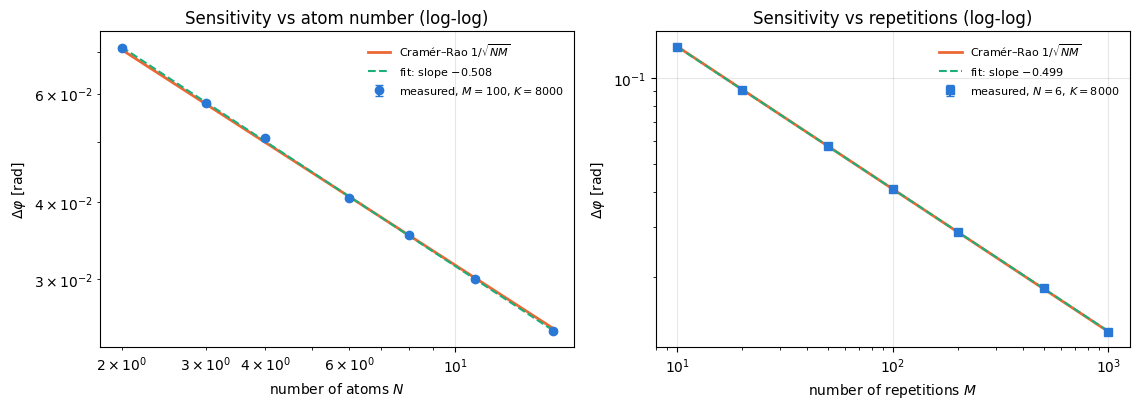

In [15]:
# ==============================================================================
# FIGURE 2: the standard quantum limit, measured
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].errorbar(N_LIST, sig_N, yerr=err_N, fmt="o", color=PALETTE[0], ms=6, capsize=3,
                 label=rf"measured, $M={M_FIX}$, $K={K_SWEEP}$")
nn = np.linspace(min(N_LIST), max(N_LIST), 100)
axes[0].plot(nn, 1 / np.sqrt(nn * M_FIX), color=PALETTE[1], lw=2.0,
             label=r"Cramér–Rao $1/\sqrt{NM}$")
axes[0].plot(nn, A_N * nn ** s_N, color=PALETTE[2], ls="--", lw=1.5,
             label=rf"fit: slope ${s_N:+.3f}$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"number of atoms $N$"); axes[0].set_ylabel(r"$\Delta\varphi$ [rad]")
axes[0].set_title(r"Sensitivity vs atom number (log-log)"); axes[0].legend(fontsize=8)

axes[1].errorbar(M_LIST, sig_M, yerr=err_M, fmt="s", color=PALETTE[0], ms=6, capsize=3,
                 label=rf"measured, $N={N_FIX}$, $K={K_SWEEP}$")
mm = np.linspace(min(M_LIST), max(M_LIST), 100)
axes[1].plot(mm, 1 / np.sqrt(N_FIX * mm), color=PALETTE[1], lw=2.0,
             label=r"Cramér–Rao $1/\sqrt{NM}$")
axes[1].plot(mm, A_M * mm ** s_M, color=PALETTE[2], ls="--", lw=1.5,
             label=rf"fit: slope ${s_M:+.3f}$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"number of repetitions $M$"); axes[1].set_ylabel(r"$\Delta\varphi$ [rad]")
axes[1].set_title(r"Sensitivity vs repetitions (log-log)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Both sweeps sit on the Cramér–Rao line over the whole scanned range: the measured-to-bound ratios in the tables stay within
$1.6\%$ of unity, and the fitted exponents printed above are $1.9\sigma$ ($N$ sweep) and $0.7\sigma$ ($M$ sweep) from the
predicted $-1/2$. The estimator attains the bound within the error bars.

Part of the residual $N$-sweep tension has a known origin: the $1+1/(2NM)$ correction of Section 11 is largest at the
small-$N$ end of the sweep ($1.0025$ at $N=2$ against $1.0003$ at $N=16$) and tilts the fitted slope by about $-0.001$. That
is a quarter of $\sigma_s$ — visible in principle, invisible at $K=8000$.

> **Physics insight.** The two panels look identical but mean very different things. Halving $\Delta\varphi$ by quadrupling
> $M$ costs four times the measurement *time*. Halving it by quadrupling $N$ costs four times the *atoms* but no extra time —
> which is why clock experiments work hard to trap more atoms. The aim of [notebook
> 32](./32_ghz_interferometry_heisenberg_limit.ipynb) is to make the left panel steeper: slope $-1$ instead of $-1/2$.

## 13. Failure of the protocol at the fringe extrema

Section 6 gave two warnings about the extrema $\varphi=0,\pi$, of different natures. We now test both by measurement.

**Warning 1 (perfect contrast).** Eq. (9) is a $0/0$ limit there; the bound $1/\sqrt{NM}$ is flat in $\varphi$ and remains
correct, but the *estimator* runs into the boundary of its range. Near $\varphi=0$ the true probability $p=\sin^2(\varphi/2)$
is tiny, most experiments return $k=0$, and $\arccos(1-2\hat p)$ then returns exactly $0$ whatever the true $\varphi$ was.
The estimator stops responding and acquires a bias. We call the region where its response slope
$\partial_\varphi\mathbb E[\hat\varphi]$ falls below $\tfrac12$ the **dead zone**: there the reported phase moves by less
than half of any change of the true phase.

**Warning 2 (imperfect contrast).** With $C<1$ the analytic sensitivity (11),
$\Delta\varphi=\sqrt{1-C^2\cos^2\varphi}\,/\,(C\vert\sin\varphi\vert\sqrt{NM})$, genuinely **diverges** at the extrema,
because the noise no longer vanishes there while the slope still does.

We therefore scan the whole fringe twice, at $C=1$ and at $C=0.8$, and record for each $\varphi$ the mean of $\hat\varphi$
(the *response curve*) and its spread.

### 13.1 The Cramér–Rao bound for a *biased* estimator

The spread we are about to measure will fall **below** $1/\sqrt{NM}$ near the extrema at $C=1$. This does not violate
Eq. (2), which holds for unbiased estimators only. The general statement, which we will need, carries the
derivative of the bias. Write $b(\varphi)=\mathbb E[\hat\varphi]-\varphi$. Repeating the standard Cauchy–Schwarz derivation
of the Cramér–Rao inequality with $\mathbb E[\hat\varphi]=\varphi+b(\varphi)$ in place of $\varphi$ replaces the numerator
$1$ by $\partial_\varphi\mathbb E[\hat\varphi]=1+b'(\varphi)$:

$$\mathrm{Var}(\hat\varphi)\ \ge\ \frac{\big(1+b'(\varphi)\big)^2}{M\,F_C(\varphi)}. \tag{16}$$

Two things follow. An estimator whose response curve is *flatter* than the diagonal, $b'<0$, is allowed a smaller variance —
in the extreme case $b'=-1$ (an estimator that ignores the data) the bound is zero, which is why "small variance" on its own
is never evidence of a good estimator. Second, the figure of merit of a biased estimator is the mean squared error,
$\mathrm{bias}^2+\mathrm{Var}\ge b^2+(1+b')^2/(MF_C)$, which can lie below $1/(MF_C)$ at a single phase; this is what the
RMS columns of the tables and the dashed curves below report.

Equation (16) is a sharp, checkable statement, so we check it. For this estimator no sampling is needed: as in
Section 11.1, $\mathbb E[\hat\varphi]$ and $\mathrm{Var}(\hat\varphi)$ are exact sums over the $NM+1$ possible counts,
and $b'(\varphi)$ follows by differentiating the exact mean numerically. The cell after the scan does this and asserts
(16) at all $31$ scanned phases for both contrasts.

In [16]:
# ==============================================================================
# STEP 9: scan the fringe at two contrasts -- response curve, bias, spread
# ==============================================================================
N_SC, M_SC, K_SC = 6, 100, 4000
PHI_SCAN = np.linspace(0.02, np.pi - 0.02, 31)
CONTRASTS = (1.0, 0.8)
scan = {}
key = jax.random.PRNGKey(555)
for C in CONTRASTS:
    mean_e, sig_e = [], []
    for phi in PHI_SCAN:
        key, sub = jax.random.split(key)
        k = ramsey_counts_fast(sub, float(phi), N_SC, M_SC, K_SC, contrast=C)
        est = np.asarray(phi_hat_mom(k, N_SC, M_SC, contrast=C))
        mean_e.append(est.mean()); sig_e.append(est.std(ddof=1))
    scan[C] = (np.array(mean_e), np.array(sig_e))

crb_sc = 1 / np.sqrt(N_SC * M_SC)
crb_phi = {C: np.asarray(1 / np.sqrt(M_SC * cfi_binomial(jnp.asarray(PHI_SCAN), N_SC, C))) for C in CONTRASTS}

print(f"N = {N_SC}, M = {M_SC}, K = {K_SC} experiments per point")
for C in CONTRASTS:
    mean_e, sig_e = scan[C]
    bias = mean_e - PHI_SCAN
    rms = np.sqrt(bias ** 2 + sig_e ** 2)
    print(f"\ncontrast C = {C}:   flat-contrast bound 1/sqrt(NM) = {crb_sc:.6f} rad")
    print(f"{'phi':>8s} {'E[phi_hat]':>12s} {'bias':>11s} {'+- SE':>9s} {'Delta phi':>11s} {'Eq. (11)':>11s} "
          f"{'RMS/Eq.(11)':>13s}")
    for i in (0, 1, 2, 5, 10, 15, 20, 25, 28, 29, 30):
        print(f"{PHI_SCAN[i]:8.4f} {mean_e[i]:12.5f} {bias[i]:+11.5f} {sig_e[i] / np.sqrt(K_SC):9.5f} "
              f"{sig_e[i]:11.6f} {crb_phi[C][i]:11.6f} {rms[i] / crb_phi[C][i]:13.4f}")

N = 6, M = 100, K = 4000 experiments per point

contrast C = 1.0:   flat-contrast bound 1/sqrt(NM) = 0.040825 rad
     phi   E[phi_hat]        bias     +- SE   Delta phi    Eq. (11)   RMS/Eq.(11)
  0.0200      0.00495    -0.01505   0.00031    0.019642    0.040825        0.6061
  0.1234      0.11422    -0.00916   0.00078    0.049607    0.040825        1.2357
  0.2268      0.22300    -0.00378   0.00065    0.041149    0.040825        1.0122
  0.5369      0.53533    -0.00161   0.00065    0.041157    0.040825        1.0089
  1.0539      1.05370    -0.00016   0.00063    0.039692    0.040825        0.9723
  1.5708      1.57070    -0.00010   0.00065    0.041105    0.040825        1.0069
  2.0877      2.08862    +0.00089   0.00064    0.040758    0.040825        0.9986
  2.6047      2.60532    +0.00066   0.00063    0.040084    0.040825        0.9820
  2.9148      2.91913    +0.00431   0.00068    0.043272    0.040825        1.0652
  3.0182      3.02833    +0.01013   0.00079    0.050094    0.04082

In [17]:
# ==============================================================================
# STEP 9b: the sub-bound spread and the biased Cramér–Rao bound, Eq. (16)
# ==============================================================================
def bias_slope(phi, N, shots, contrast=1.0, h=1e-4):
    """d E[phi_hat] / d phi = 1 + b'(phi), by a central difference on the EXACT mean."""
    return (mom_moments_exact(phi + h, N, shots, contrast)[0]
            - mom_moments_exact(phi - h, N, shots, contrast)[0]) / (2 * h)


# --- CHECKPOINT: Var(phi_hat) >= (1 + b')^2 / (M F) at EVERY scanned phase, both contrasts ----------
print("Eq. (16): the biased Cramér–Rao bound, checked against the exact binomial moments\n")
print(f"{'C':>5s} {'phi':>8s} {'sd exact':>10s} {'sd sampled':>11s} {'1 + b prime':>12s} "
      f"{'bound Eq.(16)':>14s} {'sd / bound':>11s} {'sd / Eq.(11)':>13s}")
worst_ratio, worst_z = np.inf, 0.0
exact = {}
for C in CONTRASTS:
    m_x_all, sd_x_all = [], []
    for i in range(len(PHI_SCAN)):                                 # ALL 31 phases; a subset is printed
        phi = float(PHI_SCAN[i])
        m_x, var_x = mom_moments_exact(phi, N_SC, M_SC, C)
        sd_x = float(jnp.sqrt(var_x))
        m_x_all.append(float(m_x)); sd_x_all.append(sd_x)
        slope = float(bias_slope(phi, N_SC, M_SC, C))
        fisher = float(cfi_binomial(phi, N_SC, C))                 # per repetition
        bound = abs(slope) / np.sqrt(M_SC * fisher)                # Eq. (16)
        worst_ratio = min(worst_ratio, sd_x / bound)
        # the sampled mean of Section 13 against the exact mean, in units of its standard error
        worst_z = max(worst_z, abs(scan[C][0][i] - float(m_x)) / (sd_x / np.sqrt(K_SC)))
        if i in (0, 1, 2, 5, 15, 25, 29, 30):
            print(f"{C:5.1f} {phi:8.4f} {sd_x:10.6f} {scan[C][1][i]:11.6f} {slope:12.4f} "
                  f"{bound:14.6f} {sd_x / bound:11.4f} {sd_x / crb_phi[C][i]:13.4f}")
    exact[C] = (np.array(m_x_all), np.array(sd_x_all))
print(f"\nsmallest  sd / (biased Cramér–Rao bound)  over all 31 phases and both contrasts: "
      f"{worst_ratio:.4f}   (must be >= 1)")
print(f"largest |sampled mean - exact mean| / SE over all 62 scan points: {worst_z:.2f}")
assert worst_z < 4.0, "the sampled response curve disagrees with the exact binomial sum"
assert worst_ratio > 0.995, "the biased Cramér–Rao bound Eq. (16) is violated -- a bug, not physics"
# power: the FLAT bound 1/sqrt(NM) is violated by the same numbers, which is the point of the test.
flat_worst = min(float(jnp.sqrt(mom_moments_exact(float(PHI_SCAN[i]), N_SC, M_SC, 1.0)[1])) / crb_sc
                 for i in (0, 30))
print(f"the same estimator sits at {flat_worst:.3f} x the UNBIASED bound 1/sqrt(NM) at the fringe edges, "
      f"so the test above is not vacuous")
assert flat_worst < 0.6

Eq. (16): the biased Cramér–Rao bound, checked against the exact binomial moments

    C      phi   sd exact  sd sampled  1 + b prime  bound Eq.(16)  sd / bound  sd / Eq.(11)


  1.0   0.0200   0.019417    0.019642       0.4732       0.019320      1.0050        0.4756
  1.0   0.1234   0.050010    0.049607       1.1520       0.047030      1.0634        1.2250
  1.0   0.2268   0.042136    0.041149       1.0214       0.041698      1.0105        1.0321
  1.0   0.5369   0.041008    0.041157       1.0033       0.040959      1.0012        1.0045
  1.0   1.5708   0.040859    0.041105       1.0008       0.040859      1.0000        1.0008
  1.0   2.6047   0.041008    0.040084       1.0033       0.040959      1.0012        1.0045
  1.0   3.0182   0.050010    0.050094       1.1520       0.047030      1.0634        1.2250
  1.0   3.1216   0.019417    0.018516       0.4732       0.019320      1.0050        0.4756
  0.8   0.0200   0.120908    0.119786       0.0709       0.108555      1.1138        0.0789
  0.8   0.1234   0.129447    0.129107       0.4757       0.119922      1.0794        0.5135
  0.8   0.2268   0.136703    0.136326       0.9235       0.131295      1.0412   

C = 1.0:  dead zone (response slope < 1/2) for phi < 0.021 and phi > pi - 0.021;  largest slope 1.207 at phi = 0.090
C = 0.8:  dead zone (response slope < 1/2) for phi < 0.130 and phi > pi - 0.130;  largest slope 1.127 at phi = 0.338


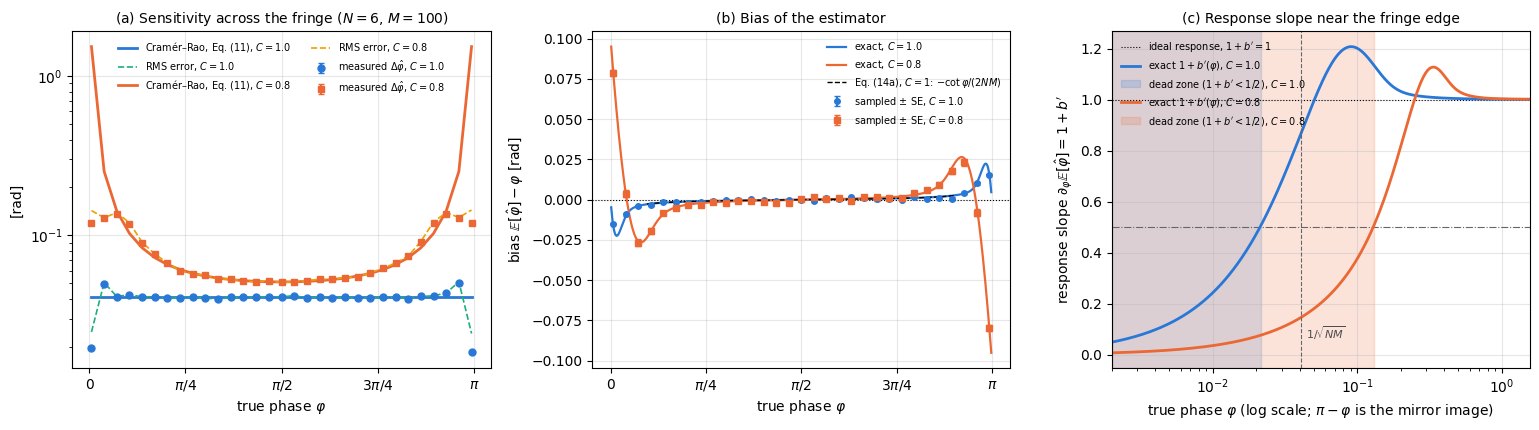

In [18]:
# ==============================================================================
# FIGURE 3: the estimator across the fringe -- sensitivity, bias, response slope
# ==============================================================================
# exact bias and response slope 1 + b' on fine grids (vmap over phi; N_SC, M_SC are closed over, so static)
PHI_FINE = np.linspace(0.005, np.pi - 0.005, 600)
PHI_LOG = np.geomspace(0.002, np.pi / 2, 400)                      # left half; the right half is its mirror image
bias_fine, slope_log, dead_edge = {}, {}, {}
for C in CONTRASTS:
    mean_fn = jax.vmap(lambda ph: mom_moments_exact(ph, N_SC, M_SC, C)[0])
    bias_fine[C] = np.asarray(mean_fn(jnp.asarray(PHI_FINE))) - PHI_FINE
    h = 1e-4
    slope_log[C] = np.asarray(mean_fn(jnp.asarray(PHI_LOG + h)) - mean_fn(jnp.asarray(PHI_LOG - h))) / (2 * h)
    dead_edge[C] = float(PHI_LOG[np.argmax(slope_log[C] >= 0.5)])      # first phase with 1 + b' >= 1/2
    print(f"C = {C}:  dead zone (response slope < 1/2) for phi < {dead_edge[C]:.3f} and phi > pi - "
          f"{dead_edge[C]:.3f};  largest slope {slope_log[C].max():.3f} at phi = {PHI_LOG[slope_log[C].argmax()]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
ticks = ([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi], ["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

for j, C in enumerate(CONTRASTS):
    mean_e, sig_e = scan[C]
    rms = np.sqrt((mean_e - PHI_SCAN) ** 2 + sig_e ** 2)
    axes[0].plot(PHI_SCAN, crb_phi[C], color=PALETTE[j], lw=2.0,
                 label=rf"Cramér–Rao, Eq. (11), $C={C}$")
    axes[0].errorbar(PHI_SCAN, sig_e, yerr=std_of_std(sig_e, K_SC), fmt=MARKERS[j], color=PALETTE[j],
                     ms=5, capsize=2, ls="none", label=rf"measured $\Delta\hat\varphi$, $C={C}$")
    axes[0].plot(PHI_SCAN, rms, ls="--", lw=1.2, color=PALETTE[j + 2],
                 label=rf"RMS error, $C={C}$")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"true phase $\varphi$"); axes[0].set_ylabel(r"[rad]")
axes[0].set_xticks(ticks[0]); axes[0].set_xticklabels(ticks[1])
axes[0].set_title(rf"(a) Sensitivity across the fringe ($N={N_SC}$, $M={M_SC}$)", fontsize=10)
axes[0].legend(fontsize=7, ncol=2, loc="upper center")

axes[1].axhline(0, color="k", lw=0.8, ls=":")
for j, C in enumerate(CONTRASTS):
    mean_e, sig_e = scan[C]
    axes[1].plot(PHI_FINE, bias_fine[C], color=PALETTE[j], lw=1.6, label=rf"exact, $C={C}$")
    axes[1].errorbar(PHI_SCAN, mean_e - PHI_SCAN, yerr=sig_e / np.sqrt(K_SC), fmt=MARKERS[j], color=PALETTE[j],
                     ms=4, capsize=2, ls="none", label=rf"sampled $\pm$ SE, $C={C}$")
ph_d = np.linspace(0.3, np.pi - 0.3, 200)
axes[1].plot(ph_d, -1 / (2 * N_SC * M_SC * np.tan(ph_d)), color="k", ls="--", lw=1.0,
             label=r"Eq. (14a), $C=1$: $-\cot\varphi/(2NM)$")
axes[1].set_xlabel(r"true phase $\varphi$"); axes[1].set_ylabel(r"bias $\mathbb{E}[\hat\varphi]-\varphi$ [rad]")
axes[1].set_xticks(ticks[0]); axes[1].set_xticklabels(ticks[1])
axes[1].set_title("(b) Bias of the estimator", fontsize=10)
axes[1].legend(fontsize=7, loc="upper right")

axes[2].axhline(1, color="k", lw=0.8, ls=":", label=r"ideal response, $1+b'=1$")
axes[2].axhline(0.5, color="0.4", lw=0.8, ls="-.")
for j, C in enumerate(CONTRASTS):
    axes[2].plot(PHI_LOG, slope_log[C], color=PALETTE[j], lw=2.0, label=rf"exact $1+b'(\varphi)$, $C={C}$")
    axes[2].axvspan(PHI_LOG[0], dead_edge[C], color=PALETTE[j], alpha=0.18,
                    label=rf"dead zone ($1+b'<1/2$), $C={C}$")
axes[2].axvline(1 / np.sqrt(N_SC * M_SC), color="0.4", lw=0.8, ls="--")
axes[2].text(1.08 / np.sqrt(N_SC * M_SC), 0.06, r"$1/\sqrt{NM}$", fontsize=8, color="0.3")
axes[2].set_xscale("log"); axes[2].set_xlim(PHI_LOG[0], PHI_LOG[-1])
axes[2].set_xlabel(r"true phase $\varphi$ (log scale; $\pi-\varphi$ is the mirror image)")
axes[2].set_ylabel(r"response slope $\partial_\varphi\mathbb{E}[\hat\varphi]=1+b'$")
axes[2].set_title("(c) Response slope near the fringe edge", fontsize=10)
axes[2].legend(fontsize=7, loc="upper left")
fig.tight_layout(); plt.show()

The tables and the figure confirm both warnings, and the two failure modes look quite different.

* **Central region.** For $\varphi$ between about $0.4$ and $2.7$ the measured spread lies on the Cramér–Rao curve for both
  contrasts (ratios between $0.97$ and $1.06$ in the tables). The bias there is small but not zero: it is the
  delta-method bias of Eq. (14a), at most $6\cdot10^{-3}$ rad in the printed rows (at $C=0.8$, $\varphi=2.60$:
  $+0.0059\pm0.0012$), and panel (b) shows the sampled points on the exact curve everywhere (largest deviation
  $2.7$ standard errors over all $62$ scan points). Here the interferometer works as advertised.
* **Imperfect contrast, $C=0.8$ (warning 2).** The bound of Eq. (11) rises steeply towards both edges — a genuine
  divergence, clearly visible on the logarithmic axis of panel (a) — and the measured points follow it up:
  $\Delta\hat\varphi$ grows from $0.0507$ at mid-fringe to $0.136$ at $\varphi=0.227$, a factor of $2.7$. Further in, the
  measured spread *stops* following the bound and saturates near $0.13$ rad, because $\hat\varphi$ is confined to
  $[0,\pi]$ and the data have become uninformative: at $\varphi=0.02$ the estimator reports $0.098\pm0.120$, which says
  nothing about a phase of $0.02$. Panel (c) quantifies this: the response slope drops below $\tfrac12$ for
  $\varphi<0.130$ (and $\varphi>\pi-0.130$), and is $0.07$ at $\varphi=0.02$.
* **Perfect contrast, $C=1$ (warning 1).** The bound stays flat at $1/\sqrt{NM}=0.0408$, and yet the measured spread falls
  below it at the edges, down to $0.0185$. Eq. (2) constrains **unbiased** estimators only, and this estimator is biased
  there. Its dead zone is narrow: the response slope is below $\tfrac12$ only for $\varphi<0.021$, roughly half of
  $1/\sqrt{NM}=0.041$, and at $\varphi=0.02$ the mean estimate is $0.0050$. Between the dead zone and the central region
  the response *overshoots*, with slope $1.21$ at $\varphi\approx0.09$ (panel (c)); that is why the spread at
  $\varphi=0.123$ lies about $22\%$ *above* the flat bound, and Eq. (16) accounts for it.

  The checkpoint above turns this into numbers. At $\varphi=0.02$ with $C=1$ the exact response slope is $1+b'=0.473$,
  so the bound of Eq. (16) is $0.473/\sqrt{NM}=0.0193$, and the exact standard deviation of the estimator is $0.0194$,
  i.e. $1.005$ times its bound. The factor by which the estimator appears to "beat" the flat bound, $0.4756$, is the
  factor by which its response curve is flattened. Over all $31$ phases and both contrasts the smallest ratio to
  Eq. (16) is $1.0000$ (attained at mid-fringe, where $b'\approx1/(2NM)$ is negligible); the smallest ratio to the
  unbiased bound is $0.476$. The sub-bound spread is a consequence of the bias, and the correct bound holds everywhere.
* The single figure of merit that does not depend on the bias is the **root-mean-square error**
  $\sqrt{\mathrm{bias}^2+\Delta\hat\varphi^2}$ (dashed in panel (a)). It exceeds the Cramér–Rao curve wherever the bias
  matters — by $24\%$ at $\varphi=0.123$ for $C=1$ — and falls below it only in the dead zone, where the estimator has
  stopped responding to the phase.

> **Common pitfall.** Quoting a standard deviation as "the error" is only meaningful for an unbiased estimator. Whenever a
> parameter sits near the boundary of its allowed range — here $\hat p\ge0$ forces $\hat\varphi\ge0$ — measure the bias
> first, plot the *response curve*, and report the RMS error.

The practical consequence is the operating rule of clocks: **operate at mid-fringe**. There the estimator is unbiased, the
response is linear, the sensitivity is best for any contrast, and the Cramér–Rao bound is attained up to the
$1+1/(2NM)$ correction of Section 11.

## 14. Phase wrapping: the interferometer's blind spots

The outcome probability $p(\varphi)=\sin^2(\varphi/2)$ is $2\pi$-periodic *and* even:

$$p(\varphi)=p(-\varphi)\qquad\text{and}\qquad p(\varphi)=p(\varphi+2\pi).$$

Neither a better estimator nor more repetitions of this protocol can distinguish $\varphi$ from $-\varphi$ or from
$\varphi+2\pi k$. The likelihood function (15) is literally identical at those points. The unambiguous window of a Ramsey
interferometer therefore has width $\pi$; conventionally $\varphi\in[0,\pi]$, which is the interval our grid search uses.

In frequency language, $\varphi=\delta T$ means that the protocol determines $\vert\delta\vert$ unambiguously only for
$\vert\delta\vert<\pi/T$, and never determines the sign of $\delta$; the longer the interrogation, the finer the resolution
*and the narrower the window*. Shifting the phase of the second pulse by $\pi/2$ (Section 16.3) makes the fringe odd in
$\delta$, $p=\tfrac12(1+C\sin\delta T)$, which resolves the sign inside the window $\vert\delta T\vert<\pi/2$, again of
width $\pi$. Clocks handle the remaining ambiguity with a servo loop that keeps $\delta$ near zero, or with a sequence of
interrogations of increasing $T$, each one refining the previous estimate. The same
problem returns $N$ times worse in [notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb).

The cell below demonstrates the aliasing by plotting the likelihood produced by one data set over an extended range.

In [19]:
# ==============================================================================
# STEP 10: the likelihood function, and the phases it cannot tell apart
# ==============================================================================
N_AL, M_AL = 6, 100
phi_true_al = 0.9
k_al = int(ramsey_counts_fast(jax.random.PRNGKey(31), phi_true_al, N_AL, M_AL, 1)[0])
phi_ext = jnp.linspace(-2 * np.pi, 2 * np.pi, 3000)
ll = np.asarray(jax.vmap(lambda p: log_likelihood(p, k_al, N_AL * M_AL))(phi_ext))
ll = ll - ll.max()

ll_max = float(jnp.max(jax.vmap(lambda p: log_likelihood(p, k_al, N_AL * M_AL))(phi_ext)))
aliases = np.array([phi_true_al, -phi_true_al, phi_true_al - 2 * np.pi, -phi_true_al + 2 * np.pi])
print(f"one experiment: N = {N_AL}, M = {M_AL}, phi_true = {phi_true_al}, k = {k_al} excited detections "
      f"out of {N_AL * M_AL}")
print(f"estimate inside the window [0, pi]: {float(phi_hat_mom(k_al, N_AL, M_AL)):.6f}")
print("\nlog-likelihood at the four aliases (identical by symmetry):")
for a in aliases:
    print(f"   phi = {a:+7.4f}   ln L(phi) - ln L_max = "
          f"{float(log_likelihood(a, k_al, N_AL * M_AL)) - ll_max:+.9f}")

one experiment: N = 6, M = 100, phi_true = 0.9, k = 88 excited detections out of 600
estimate inside the window [0, pi]: 0.786020

log-likelihood at the four aliases (identical by symmetry):
   phi = +0.9000   ln L(phi) - ln L_max = -3.768579836
   phi = -0.9000   ln L(phi) - ln L_max = -3.768579836
   phi = -5.3832   ln L(phi) - ln L_max = -3.768579836
   phi = +5.3832   ln L(phi) - ln L_max = -3.768579836


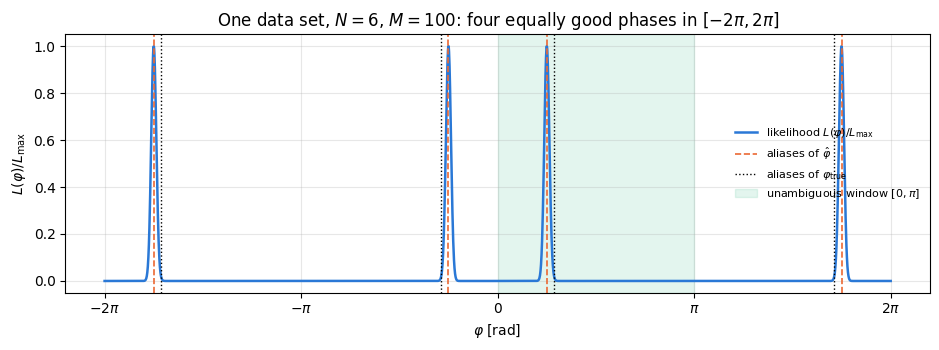

In [20]:
# ==============================================================================
# FIGURE 4: aliasing of the Ramsey phase
# ==============================================================================
phi_est = float(phi_hat_mom(k_al, N_AL, M_AL))
est_aliases = np.array([phi_est, -phi_est, phi_est - 2 * np.pi, -phi_est + 2 * np.pi])
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(np.asarray(phi_ext), np.exp(ll), color=PALETTE[0], lw=1.8, label=r"likelihood $L(\varphi)/L_{\max}$")
for j, a in enumerate(est_aliases):
    ax.axvline(a, color=PALETTE[1], ls="--", lw=1.2,
               label=r"aliases of $\hat\varphi$" if j == 0 else None)
for j, a in enumerate(aliases):
    ax.axvline(a, color="k", ls=":", lw=1.0,
               label=r"aliases of $\varphi_{\mathrm{true}}$" if j == 0 else None)
ax.axvspan(0, np.pi, color=PALETTE[2], alpha=0.12, label=r"unambiguous window $[0,\pi]$")
ax.set_xlabel(r"$\varphi$ [rad]"); ax.set_ylabel(r"$L(\varphi)/L_{\max}$")
ax.set_xticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi])
ax.set_xticklabels([r"$-2\pi$", r"$-\pi$", "0", r"$\pi$", r"$2\pi$"])
ax.set_title(rf"One data set, $N={N_AL}$, $M={M_AL}$: four equally good phases in $[-2\pi,2\pi]$")
ax.legend(fontsize=8, loc="center right")
fig.tight_layout(); plt.show()

Four peaks of exactly equal height inside $[-2\pi,2\pi]$, at $\pm\hat\varphi$ and $\pm\hat\varphi\mp2\pi$ — and the pattern
repeats with period $2\pi$. The printed log-likelihoods at the four aliases of the *true* phase are identical to all digits
shown, which is the statement that no amount of data from this protocol can separate them. The data determine the phase
only up to this set of aliases; restricting the estimator to the shaded window is prior knowledge that the measurement
does not provide. (The
dotted lines mark $\pm0.9$, the true phase; the dashed lines mark the maximum-likelihood estimate, which differs from it by
one statistical fluctuation of a single $M=100$ experiment.)

## 15. Decoherence during the interrogation

### 15.1 Dephasing and the contrast $e^{-\gamma T}$

During the free evolution the atoms are not isolated: fluctuating fields randomise the relative phase between $\vert0\rangle$
and $\vert1\rangle$. The simplest model is **Markovian dephasing**, described for each atom by the
master equation

$$\frac{d\rho}{dt}=-i[\delta J_z,\rho]+\frac{\gamma}{2}\big(Z\rho Z-\rho\big).$$

The dissipator leaves the populations alone and attacks only the coherence: writing $\rho_{01}$ for the off-diagonal element,
$Z\rho Z$ flips its sign, so $\dot\rho_{01}=(i\cdot\text{phase})-\gamma\rho_{01}$ and

$$\vert\rho_{01}(T)\vert=e^{-\gamma T}\vert\rho_{01}(0)\vert. \tag{17}$$

Because the signal (7) is the projection of the *equatorial* component of the Bloch vector, and that component is exactly
$2\vert\rho_{01}\vert$, the effect on the measured fringe is a reduced **contrast**:

$$p(\varphi)=\frac{1-C\cos\varphi}{2},\qquad C=e^{-\gamma T}. \tag{18}$$

### 15.2 The same statement as a channel

The engine implements dephasing as the Kraus channel $\rho\mapsto(1-p_d)\rho+p_dZ\rho Z$, whose coherence factor is
$1-2p_d$. Applying it $n$ times with $p_d=\gamma\,dt/2$ gives $(1-\gamma\,dt)^n\to e^{-\gamma T}$ as $dt=T/n\to0$, so a
single application with

$$p_d=\frac{1-e^{-\gamma T}}{2} \tag{19}$$

reproduces (17) **exactly**, with no Trotter error. (This works because the dephasing channel commutes with the phase
encoding $e^{-i\varphi J_z}$: both are diagonal in the computational basis. Noise "during" the interrogation and noise
"after" it are therefore the same map here — a convenience we will lose in other channels.)

### 15.3 Effect on the Fisher informations

After dephasing the $N$-atom state is still a *product* of identical one-atom mixed states, with Bloch vector
$\mathbf r=(C\cos\varphi,\ C\sin\varphi,\ 0)$. Quantum Fisher information is additive over a product state, so
$F_Q=N\,F_Q^{(1)}$, and $F_Q^{(1)}$ follows from Eq. (4) in the two-dimensional eigenbasis of $\rho$: the eigenvalues are
$\lambda_\pm=(1\pm\vert\mathbf r\vert)/2$, so $\lambda_++\lambda_-=1$ and $(\lambda_+-\lambda_-)^2=\vert\mathbf r\vert^2$, and
with $G=Z/2$,

$$F_Q^{(1)}=2\cdot2\cdot\frac{\vert\mathbf r\vert^2}{1}\,\big\vert\langle\lambda_+\vert\tfrac Z2\vert\lambda_-\rangle\big\vert^2
=4\vert\mathbf r\vert^2\cdot\frac14\Big(1-\frac{r_z^2}{\vert\mathbf r\vert^2}\Big)=r_x^2+r_y^2=C^2 .$$

(We used the standard Bloch identity $\vert\langle\lambda_+\vert Z\vert\lambda_-\rangle\vert^2=1-(r_z/\vert\mathbf r\vert)^2$ for the
eigenvectors $\vert\lambda_\pm\rangle$ of a qubit density matrix.) Hence

$$F_Q=NC^2=N e^{-2\gamma T}. \tag{20}$$

Equation (20) holds at **every** $\varphi$: the dephasing channel commutes with the encoding $e^{-i\varphi J_z}$, so
rotating the state about $z$ cannot change a quantity built from the generator $J_z$.

The classical Fisher information of the readout does *not* share that property. From `cfi_binomial` with contrast $C$,

$$F_C(\varphi)=\frac{NC^2\sin^2\varphi}{1-C^2\cos^2\varphi}\ \le\ NC^2=F_Q, \tag{21}$$

with equality **only** at mid-fringe. (Substituting $u=\cos^2\varphi$ turns the ratio into $(1-u)/(1-C^2u)$, whose
derivative $(C^2-1)/(1-C^2u)^2$ is negative for $C<1$: the information decreases monotonically as one moves away from
$u=0$, i.e. away from $\varphi=\pi/2$.) At $C=1$ the two cancel and $F_C$ is flat, which is the special situation of
Section 7; as soon as $C<1$, atom counting is optimal at one operating point and strictly sub-optimal everywhere else.
**The Ramsey readout is still optimal, provided you sit at mid-fringe**, and there

$$\Delta\varphi=\frac{1}{C\sqrt{NM}}=\frac{e^{\gamma T}}{\sqrt{NM}}. \tag{22}$$

### 15.4 Amplitude damping, for comparison

If instead the excited state *decays* with probability $g$ during the interrogation (the engine's
`kraus_amplitude_damping`), the channel is **non-unital**: besides shrinking the Bloch vector, it also pushes it
towards the pole. We use $\sigma^\pm=(X\pm iY)/2$, so that $\sigma^-=\vert1\rangle\langle0\vert$ lowers spin up $\vert0\rangle$ to
spin down $\vert1\rangle$ and $\sigma^+=\vert0\rangle\langle1\vert$ raises it; the decay $\vert1\rangle\to\vert0\rangle$ is therefore $\sigma^+$.
Starting from the encoded equatorial state $(\cos\varphi,\sin\varphi,0)$, the Kraus pair
$K_0=\mathrm{diag}(1,\sqrt{1-g})$, $K_1=\sqrt g\,\sigma^+$ gives

$$\mathbf r=\big(\sqrt{1-g}\cos\varphi,\ \sqrt{1-g}\sin\varphi,\ g\big),$$

so the equatorial part shrinks by $\sqrt{1-g}$ while $r_z$ moves from $0$ to $g$. The QFI formula derived above,
$F_Q^{(1)}=r_x^2+r_y^2$, holds for *any* qubit state and therefore still applies: $F_Q=N(1-g)$, **exactly**, with no
small-$g$ expansion — the shift along $z$ costs nothing because $F_Q^{(1)}=\vert\mathbf r\vert^2-r_z^2$ and the two extra
$g^2$ terms cancel. The shift is likewise invisible in the signal: the final $\pi/2$ pulse maps $(x,y,z)\mapsto(-z,y,x)$,
so what the atom counter reads is $r_x$, and $r_z$ ends up along an axis that is never measured. The readout probability is
again $p=(1-C\cos\varphi)/2$ with $C=\sqrt{1-g}$, so Eq. (22) applies unchanged. (Amplitude damping also commutes with the
encoding as a *map* — $R_z\sigma^+R_z^\dagger=e^{-i\varphi}\sigma^+$, and the phase cancels between $K$ and $K^\dagger$ —
so "during" and "after" again coincide.)

All of this is now checked against the engine.

In [21]:
# ==============================================================================
# STEP 11: noisy Ramsey on the exact density tensor -- contrast, CFI and QFI
# ==============================================================================
def noisy_readout_dm(N, phi, kraus):
    """Density tensor at readout when a local channel acts during the interrogation.

    PIPELINE  |0>^N -> Ry(+pi/2) -> Rz(phi) -> channel on every atom -> Ry(-pi/2)
    (the channel and Rz(phi) commute for dephasing and amplitude damping, so the order inside the
     interrogation window is irrelevant -- see Section 15.2.)
    COST  O(4^N) memory: small N only.
    """
    rho = to_dm(collective_pulse(zero_state(N), ry(jnp.pi / 2)))
    for q in range(N):
        rho = apply_gate_dm(rho, rz(phi), [q])
    for q in range(N):
        rho = apply_kraus_dm(rho, kraus, [q])
    for q in range(N):
        rho = apply_gate_dm(rho, ry(-jnp.pi / 2), [q])
    return rho


def p_excited_dm(rho):
    """P(atom 0 is found excited) from the one-atom reduced density matrix of a density tensor."""
    return float(jnp.real(rdm_dm(rho, [0])[1, 1]))


def qfi_after_channel(N, kraus, generator=Z):
    """QFI of the ENCODED state (after the channel, before the final pulse) for the generator J_z."""
    rho = to_dm(collective_pulse(zero_state(N), ry(jnp.pi / 2)))
    for q in range(N):
        rho = apply_kraus_dm(rho, kraus, [q])
    return float(qfi_mixed(dm_matrix(rho), collective_dense(generator, N)))


N_NZ = 4
print(f"N = {N_NZ}.  DEPHASING with p_d = (1 - exp(-gamma T))/2, Eq. (19)\n")
print(f"{'gamma*T':>8s} {'C = exp(-gT)':>13s} {'p_exc(phi=1) DM':>16s} {'(1-C cos1)/2':>14s} "
      f"{'QFI engine':>12s} {'N C^2':>10s} {'CFI mid-fringe':>15s}")
err_deph = 0.0
for gT in (0.0, 0.2, 0.5, 1.0, 2.0):
    C = np.exp(-gT)
    pd = (1 - C) / 2
    rho = noisy_readout_dm(N_NZ, 1.0, kraus_dephasing(pd))
    pe = p_excited_dm(rho)
    pred = (1 - C * np.cos(1.0)) / 2
    fq = qfi_after_channel(N_NZ, kraus_dephasing(pd))
    cfi = float(cfi_binomial(np.pi / 2, N_NZ, C))
    err_deph = max(err_deph, abs(pe - pred), abs(fq - N_NZ * C ** 2), abs(cfi - N_NZ * C ** 2))
    print(f"{gT:8.2f} {C:13.6f} {pe:16.9f} {pred:14.9f} {fq:12.6f} {N_NZ * C ** 2:10.6f} {cfi:15.6f}")
print(f"\nlargest deviation from Eqs. (18)-(21): {err_deph:.2e}")
assert err_deph < 1e-9

print(f"\nAMPLITUDE DAMPING with decay probability g\n")
print(f"{'g':>8s} {'C = sqrt(1-g)':>14s} {'p_exc(phi=1) DM':>16s} {'(1-C cos1)/2':>14s} "
      f"{'QFI engine':>12s} {'N(1-g)':>10s}")
err_ad = 0.0
for g in (0.0, 0.1, 0.3, 0.6):
    C = np.sqrt(1 - g)
    rho = noisy_readout_dm(N_NZ, 1.0, kraus_amplitude_damping(g))
    pe = p_excited_dm(rho)
    pred = (1 - C * np.cos(1.0)) / 2
    fq = qfi_after_channel(N_NZ, kraus_amplitude_damping(g))
    err_ad = max(err_ad, abs(pe - pred), abs(fq - N_NZ * (1 - g)))
    print(f"{g:8.2f} {C:14.6f} {pe:16.9f} {pred:14.9f} {fq:12.6f} {N_NZ * (1 - g):10.6f}")
print(f"\nlargest deviation from the Section 15.4 predictions: {err_ad:.2e}")
assert err_ad < 1e-9

N = 4.  DEPHASING with p_d = (1 - exp(-gamma T))/2, Eq. (19)

 gamma*T  C = exp(-gT)  p_exc(phi=1) DM   (1-C cos1)/2   QFI engine      N C^2  CFI mid-fringe


    0.00      1.000000      0.229848847    0.229848847     4.000000   4.000000        4.000000
    0.20      0.818731      0.278818943    0.278818943     2.681280   2.681280        2.681280
    0.50      0.606531      0.336145043    0.336145043     1.471518   1.471518        1.471518
    1.00      0.367879      0.400616945    0.400616945     0.541341   0.541341        0.541341
    2.00      0.135335      0.463439017    0.463439017     0.073263   0.073263        0.073263

largest deviation from Eqs. (18)-(21): 3.11e-15

AMPLITUDE DAMPING with decay probability g

       g  C = sqrt(1-g)  p_exc(phi=1) DM   (1-C cos1)/2   QFI engine     N(1-g)
    0.00       1.000000      0.229848847    0.229848847     4.000000   4.000000
    0.10       0.948683      0.243712113    0.243712113     3.600000   3.600000
    0.30       0.836660      0.273975329    0.273975329     2.800000   2.800000
    0.60       0.632456      0.329141409    0.329141409     1.600000   1.600000

largest deviation from the Sec

Every entry matches to $4\cdot10^{-15}$: the exact density-tensor evolution, the closed-form contrast, the classical
Fisher information of the binomial readout and the symmetric-logarithmic-derivative QFI all agree. In particular
$F_C=F_Q=NC^2$ at mid-fringe for dephasing — decoherence degrades the sensitivity but does **not** make atom counting a
suboptimal measurement.

In [22]:
# ==============================================================================
# STEP 12: the noisy protocol, measured -- Delta phi against 1/(C sqrt(NM))
# ==============================================================================
N_NOISY, M_NOISY, K_NOISY = 8, 100, 3000
print(f"N = {N_NOISY}, M = {M_NOISY}, K = {K_NOISY}, operating at mid-fringe\n")
print(f"{'gamma*T':>8s} {'C':>9s} {'Delta phi measured':>20s} {'error bar':>11s} "
      f"{'1/(C sqrt(NM))':>16s} {'ratio':>8s} {'exact ratio':>12s}")
key = jax.random.PRNGKey(909)
gTs, meas, pred_l, exact_l = [], [], [], []
for gT in (0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0):
    C = float(np.exp(-gT))
    key, sub = jax.random.split(key)
    k = ramsey_counts_fast(sub, PHI_TRUE, N_NOISY, M_NOISY, K_NOISY, contrast=C)
    est = np.asarray(phi_hat_mom(k, N_NOISY, M_NOISY, contrast=C))
    s = float(est.std(ddof=1))
    crb_ = 1 / (C * np.sqrt(N_NOISY * M_NOISY))
    sd_x = float(jnp.sqrt(mom_moments_exact(PHI_TRUE, N_NOISY, M_NOISY, C)[1]))   # exact binomial sum
    gTs.append(gT); meas.append(s); pred_l.append(crb_); exact_l.append(sd_x)
    print(f"{gT:8.2f} {C:9.5f} {s:20.6f} {float(std_of_std(s, K_NOISY)):11.6f} {crb_:16.6f} {s / crb_:8.4f} "
          f"{sd_x / crb_:12.4f}")
    assert abs(s - sd_x) < 4 * float(std_of_std(sd_x, K_NOISY)), "measured spread disagrees with the exact sum"
assert abs(meas[0] / pred_l[0] - 1) < 0.1 and abs(meas[3] / pred_l[3] - 1) < 0.15

N = 8, M = 100, K = 3000, operating at mid-fringe

 gamma*T         C   Delta phi measured   error bar   1/(C sqrt(NM))    ratio  exact ratio


    0.00   1.00000             0.035154    0.000454         0.035355   0.9943       1.0006
    0.25   0.77880             0.045029    0.000581         0.045397   0.9919       1.0010
    0.50   0.60653             0.057496    0.000742         0.058291   0.9864       1.0017
    0.75   0.47237             0.075740    0.000978         0.074847   1.0119       1.0028
    1.00   0.36788             0.095971    0.001239         0.096106   0.9986       1.0047
    1.50   0.22313             0.159717    0.002062         0.158452   1.0080       1.0134
    2.00   0.13534             0.275535    0.003558         0.261243   1.0547       1.0432


The measured sensitivity tracks $e^{\gamma T}/\sqrt{NM}$ across a factor $e^2\simeq7.4$ in contrast, and every row
agrees with the exact binomial sum within four error bars (asserted). The ratios stay near unity until the contrast is
small: at $\gamma T=2$ ($C=0.135$) the exact ratio is $1.043$. This excess is the curvature of $\arccos$, the
$1+1/(2NM)$ correction of Section 11 with $NM$ replaced by $NMC^2=15$ effective detections ($1+1/30=1.033$ to that
order); clipping at the edge of the $\arccos$ domain plays no role here (it occurs with probability $10^{-4}$). Decoherence costs sensitivity *exponentially* in the interrogation time — which immediately raises the
question of the next section.

## 16. The optimal interrogation time

### 16.1 The trade-off

A clock does not want the phase $\varphi$; it wants the **frequency** $\delta=\varphi/T$. Longer interrogation multiplies the
phase (good) but destroys the contrast (bad), and a fixed total experiment time $T_{\mathrm{tot}}$ buys fewer
repetitions:

$$M=\frac{T_{\mathrm{tot}}}{T}.$$

The calculation that follows is the one Huelga and co-workers published in 1997; the reference is in Section 20, and
[notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb) carries it through for an entangled probe, which is where its
punchline lies. It rests on four assumptions, all of which the simulation below implements literally:

* the $N$ atoms are **uncorrelated** and identically prepared, so $\Delta\varphi=1/(C\sqrt{NM})$, Eq. (22);
* the noise is **Markovian dephasing** at a constant rate $\gamma$, so the contrast is $C(T)=e^{-\gamma T}$ with no memory
  and no $T$-independent floor (a laser with $1/f$ frequency noise, for instance, violates this — Exercise 7);
* there is **no dead time**: state preparation, the two pulses and the detection are instantaneous, so $M=T_{\mathrm{tot}}/T$
  exactly. Real clocks lose an appreciable fraction of $T_{\mathrm{tot}}$ to these steps, which pushes $T_{\mathrm{opt}}$ up;
* the clock is **servo-locked at mid-fringe**, $\delta\approx0$ with the $\pi/2$ offset of Section 16.3, so Eq. (22) applies
  at its best operating point and phase wrapping never arises.

Combining $M=T_{\mathrm{tot}}/T$ with Eq. (22),

$$\Delta\delta=\frac{\Delta\varphi}{T}=\frac{e^{\gamma T}}{T\sqrt{NM}}
=\frac{e^{\gamma T}}{T}\sqrt{\frac{T}{N\,T_{\mathrm{tot}}}}
=\frac{e^{\gamma T}}{\sqrt{N\,T_{\mathrm{tot}}\,T}}. \tag{23}$$

### 16.2 The optimum

Minimising (23) means minimising $f(T)=\gamma T-\tfrac12\ln T$ (the logarithm of the numerator over the square root):

$$f'(T)=\gamma-\frac{1}{2T}=0\qquad\Longrightarrow\qquad \boxed{\ T_{\mathrm{opt}}=\frac{1}{2\gamma}\ },\qquad
\gamma T_{\mathrm{opt}}=\frac12 . \tag{24}$$

Since $f''(T)=1/(2T^2)>0$ this is a minimum. Substituting back,

$$\Delta\delta_{\min}=\frac{e^{1/2}}{\sqrt{N\,T_{\mathrm{tot}}/(2\gamma)}}=\sqrt{\frac{2e\gamma}{N\,T_{\mathrm{tot}}}}. \tag{25}$$

Three readings of Eq. (25):

* the best achievable frequency uncertainty scales as $\sqrt{\gamma}$ — **halving the decoherence rate improves a clock by
  $\sqrt2$**, whatever else you do;
* it scales as $1/\sqrt N$ — the standard quantum limit survives decoherence intact;
* the optimum does not depend on $N$: interrogate for half a coherence time, whatever the atom number. (In
  [notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb) a GHZ probe moves the optimum to $1/(2N\gamma)$ and ends
  up with the same $\Delta\delta_{\min}$.)

### 16.3 Verification

We now measure it. For a grid of interrogation times $T$ we take $M=\lfloor T_{\mathrm{tot}}/T\rfloor$ repetitions, simulate
$K$ independent clock runs, estimate $\hat\delta$ and record its spread. To stay at the operating point we add the
conventional $\pi/2$ phase offset, so the fringe reads $p=\tfrac12(1+C\sin\delta T)$ and a clock running at $\delta\approx0$
sits exactly at mid-fringe.

In [23]:
# ==============================================================================
# STEP 13: frequency estimation at fixed total time -- find T_opt numerically
# ==============================================================================
GAMMA, T_TOT, N_CLOCK, K_CLOCK = 1.0, 400.0, 8, 3000     # units: gamma = 1 sets the time unit
DELTA_TRUE = 0.0                                          # the servo holds the clock on resonance


@partial(jax.jit, static_argnames=("N", "shots", "n_exp"))
def clock_counts(key, delta, T, contrast, N, shots, n_exp):
    """Ramsey clock run with the conventional pi/2 offset: p = (1 + C sin(delta T))/2.
    Returns the total number of excited detections in each of `n_exp` independent runs."""
    p = (1 + contrast * jnp.sin(delta * T)) / 2
    return jnp.sum(jax.random.bernoulli(key, p, (n_exp, shots, N)), axis=(1, 2))


def delta_hat(k, N, shots, T, contrast):
    """Invert p = (1 + C sin(delta T))/2  ->  delta = arcsin((2k/(N M) - 1)/C)/T."""
    return jnp.arcsin(jnp.clip((2 * k / (N * shots) - 1) / contrast, -1.0, 1.0)) / T


def delta_sd_exact(N, shots, T, contrast):
    """EXACT standard deviation of `delta_hat` at delta = 0 (p = 1/2), summed over all N*shots+1 counts,
    together with the probability that the arcsin argument is clipped.  Same log-gamma pmf as Section 11.1."""
    n = N * shots
    k = jnp.arange(n + 1, dtype=RDTYPE)
    P = jnp.exp(gammaln(n + 1.0) - gammaln(k + 1.0) - gammaln(n - k + 1.0) - n * jnp.log(2.0))
    x = (2 * k / n - 1) / contrast
    d = delta_hat(k, N, shots, T, contrast)
    m1 = jnp.sum(P * d)
    return float(jnp.sqrt(jnp.sum(P * d ** 2) - m1 ** 2)), float(jnp.sum(jnp.where(jnp.abs(x) >= 1, P, 0.0)))


T_GRID = np.array([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0, 1.4, 2.0, 3.0])
meas_dd, pred_dd, Ms, exact_dd, pclip = [], [], [], [], []
key = jax.random.PRNGKey(4242)
for T in T_GRID:
    M = max(int(T_TOT // T), 1)
    C = float(np.exp(-GAMMA * T))
    key, sub = jax.random.split(key)
    k = clock_counts(sub, DELTA_TRUE, float(T), C, N_CLOCK, M, K_CLOCK)
    d = np.asarray(delta_hat(k, N_CLOCK, M, float(T), C))
    meas_dd.append(float(d.std(ddof=1)))
    pred_dd.append(float(np.exp(GAMMA * T) / np.sqrt(N_CLOCK * M * T ** 2)))
    Ms.append(M)
    sd_x, pc = delta_sd_exact(N_CLOCK, M, float(T), C)
    exact_dd.append(sd_x); pclip.append(pc)
    assert abs(meas_dd[-1] - sd_x) < 4 * float(std_of_std(sd_x, K_CLOCK)), "clock spread disagrees with the exact sum"

i_meas = int(np.argmin(meas_dd))
T_fine = np.linspace(0.05, 3.0, 2000)
dd_fine = np.exp(GAMMA * T_fine) / np.sqrt(N_CLOCK * T_TOT * T_fine)
T_opt_analytic = 1 / (2 * GAMMA)

print(f"gamma = {GAMMA}, total time = {T_TOT}, N = {N_CLOCK} atoms, K = {K_CLOCK} clock runs per point\n")
print(f"{'T':>7s} {'M = T_tot/T':>12s} {'C = e^{-gT}':>12s} {'Delta delta measured':>22s} "
      f"{'error bar':>11s} {'Eq. (23)':>11s} {'ratio':>7s} {'exact ratio':>12s} {'P(clip)':>9s}")
for T, m, mm, pp, xx, pc in zip(T_GRID, Ms, meas_dd, pred_dd, exact_dd, pclip):
    print(f"{T:7.2f} {m:12d} {np.exp(-GAMMA * T):12.5f} {mm:22.6f} "
          f"{float(std_of_std(mm, K_CLOCK)):11.6f} {pp:11.6f} {mm / pp:7.4f} {xx / pp:12.4f} {pc:9.1e}")
print(f"\nanalytic optimum          T_opt = 1/(2 gamma) = {T_opt_analytic:.4f},  gamma*T_opt = {GAMMA * T_opt_analytic:.4f}")
print(f"minimum of the analytic curve (fine grid):        T = {T_fine[int(np.argmin(dd_fine))]:.4f}")
print(f"best MEASURED point on the simulated grid:        T = {T_GRID[i_meas]:.4f}   "
      f"Delta delta = {meas_dd[i_meas]:.6f}")
dd_min_theory = float(np.sqrt(2 * np.e * GAMMA / (N_CLOCK * T_TOT)))
i_opt = int(np.argmin(np.abs(T_GRID - T_opt_analytic)))
print(f"Eq. (25) sqrt(2 e gamma/(N T_tot)) = {dd_min_theory:.6f}")
print(f"measured AT T = T_opt: {meas_dd[i_opt]:.6f}  ->  ratio to Eq. (25) = {meas_dd[i_opt] / dd_min_theory:.4f} "
      f"(error bar {float(std_of_std(meas_dd[i_opt], K_CLOCK)) / dd_min_theory:.4f})")
# the position of the minimum is only resolved to one grid point (the minimum is quadratically flat, and
# neighbouring grid points differ by ~1-2%, i.e. by ~1 standard error); the VALUE at T_opt is the sharp test.
assert abs(T_GRID[i_meas] - T_opt_analytic) < 0.2
assert abs(meas_dd[i_opt] / dd_min_theory - 1) < 0.05

gamma = 1.0, total time = 400.0, N = 8 atoms, K = 3000 clock runs per point

      T  M = T_tot/T  C = e^{-gT}   Delta delta measured   error bar    Eq. (23)   ratio  exact ratio   P(clip)
   0.05         7999      0.95123               0.085143    0.001099    0.083115  1.0244       1.0000   0.0e+00
   0.10         3999      0.90484               0.062771    0.000811    0.061789  1.0159       1.0000   0.0e+00
   0.15         2666      0.86071               0.053882    0.000696    0.053037  1.0159       1.0000   0.0e+00
   0.20         1999      0.81873               0.048313    0.000624    0.048292  1.0004       1.0000   0.0e+00
   0.30         1333      0.74082               0.044010    0.000568    0.043572  1.0101       1.0001   0.0e+00
   0.40          999      0.67032               0.041179    0.000532    0.041719  0.9871       1.0001   0.0e+00
   0.50          800      0.60653               0.040838    0.000527    0.041218  0.9908       1.0002   0.0e+00
   0.65          615      0

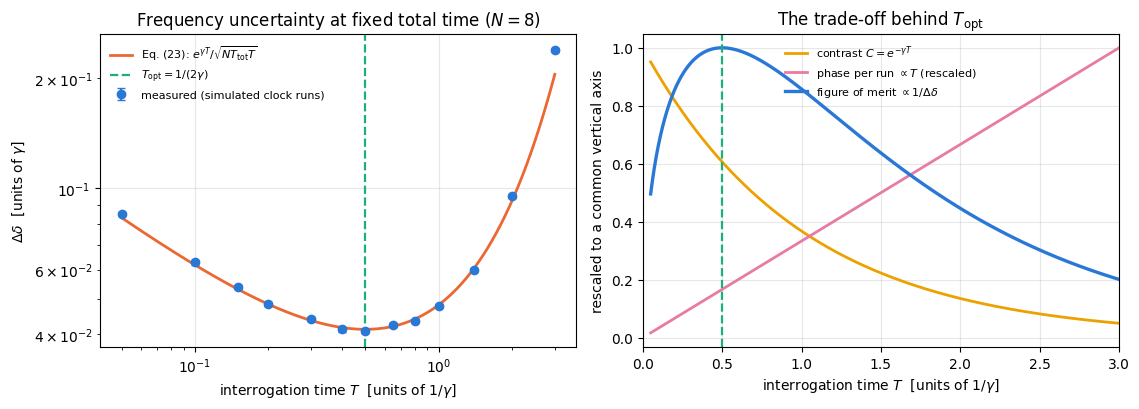

In [24]:
# ==============================================================================
# FIGURE 5: the optimal interrogation time
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].plot(T_fine, dd_fine, color=PALETTE[1], lw=2.0, label=r"Eq. (23): $e^{\gamma T}/\sqrt{N T_{\rm tot}T}$")
axes[0].errorbar(T_GRID, meas_dd, yerr=std_of_std(np.array(meas_dd), K_CLOCK), fmt="o",
                 color=PALETTE[0], ms=6, capsize=3, label="measured (simulated clock runs)")
axes[0].axvline(T_opt_analytic, color=PALETTE[2], ls="--", lw=1.6,
                label=r"$T_{\rm opt}=1/(2\gamma)$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"interrogation time $T$  [units of $1/\gamma$]")
axes[0].set_ylabel(r"$\Delta\delta$  [units of $\gamma$]")
axes[0].set_title(rf"Frequency uncertainty at fixed total time ($N={N_CLOCK}$)")
axes[0].legend(fontsize=8)

axes[1].plot(T_fine, np.exp(-GAMMA * T_fine), color=PALETTE[3], lw=2.0, label=r"contrast $C=e^{-\gamma T}$")
axes[1].plot(T_fine, T_fine / T_fine.max(), color=PALETTE[4], lw=2.0,
             label=r"phase per run $\propto T$ (rescaled)")
axes[1].plot(T_fine, np.min(dd_fine) / dd_fine, color=PALETTE[0], lw=2.4,
             label=r"figure of merit $\propto1/\Delta\delta$")
axes[1].axvline(T_opt_analytic, color=PALETTE[2], ls="--", lw=1.6)
axes[1].set_xlabel(r"interrogation time $T$  [units of $1/\gamma$]")
axes[1].set_ylabel("rescaled to a common vertical axis")
axes[1].set_xlim(0, 3.0)
axes[1].set_title("The trade-off behind $T_{\\rm opt}$")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The simulated clock runs land on the analytic curve over the scanned range up to $T\approx2/\gamma$ (the last point is
discussed below). The lowest measured point is the grid
point $T=0.5/\gamma$, which is $T_{\mathrm{opt}}=1/(2\gamma)$ from Eq. (24), and the analytic curve minimises at
$T=0.5001/\gamma$ on the fine grid (grid resolution $1.5\cdot10^{-3}$). The agreement of the *value* is the informative
statement: $0.0408\,\gamma$ against $\sqrt{2e\gamma/(NT_{\mathrm{tot}})}=0.0412\,\gamma$ from Eq. (25), a difference of
$0.9\%$ against an error bar of $1.3\%$.

The *position* of the minimum is much weaker evidence, and it is worth seeing why. Each point carries a relative error
$1/\sqrt{2(K-1)}=1.3\%$, whereas the analytic curve rises by only $1.2\%$ between $T=0.5$ and $T=0.4$ and by $1.9\%$ between
$T=0.5$ and $T=0.65$ — the minimum of $e^{\gamma T}/\sqrt T$ is quadratically flat, so the argument of the minimum over this
grid is decided by noise among its three central points. Repeating the whole scan with $200$ other seeds (binomial counts
drawn with NumPy, same estimator) confirms this: the lowest point lands on $T=0.5$ in $128$ runs, on $T=0.4$ in $51$ and
on $T=0.65$ in $21$, never further away (the
next grid points out, $T=0.3$ and $T=0.8$, lie $5.7\%$ and $6.7\%$ above the minimum, more than four standard errors). The
assert below is written accordingly: it tolerates a shift by one grid point in the position, and is tight on the value.

Both ends of the scan sit above the curve, for different reasons, and the exact column separates them. At $T=0.05$ the
measured excess is $2.4\%$, under two standard errors, while the exact ratio is $1.0000$: it is a sampling fluctuation.
At $T=3$ the measured excess is $17\%$ and the exact ratio is $1.182$, so the effect is real: the contrast has
collapsed to $C=0.05$, the argument $(2\hat p-1)/C$ of the $\arcsin$ in `delta_hat` has a standard deviation of $0.62$,
the curvature of $\arcsin$ amplifies the large excursions, and $10\%$ of the runs are clipped to $\pm1$ (column
`P(clip)`). Eq. (23) is a linear-response formula and stops applying once the estimator explores the curved part and
the edge of its range — the same failure as at the fringe extrema in Section 13, arriving here through the contrast
instead of through the phase. Every measured point agrees with its exact value within four error bars (asserted).

The right panel shows *why* there is an optimum: the useful phase per run grows linearly with $T$, the contrast falls
exponentially, and their combination — together with the fact that long runs mean few runs — peaks at half a coherence time.
Below $T_{\mathrm{opt}}$ one wastes coherence; above it one pays an exponential penalty for it.

> **Physics insight.** Within the four assumptions of Section 16.1, Equation (25) sets the frequency resolution of the
> clock. It depends on $\gamma$, $N$ and $T_{\mathrm{tot}}$ only: the readout is already optimal at mid-fringe, so a
> better estimator cannot improve it. What remains is to reduce $\gamma$ (better isolation, dynamical decoupling,
> longer-lived transitions) or to change the probe state. [Notebook 32](./32_ghz_interferometry_heisenberg_limit.ipynb)
> tries the second option with a GHZ probe and finds, under the same independent dephasing, the same
> $\Delta\delta_{\min}$ (Huelga *et al.*, 1997).

## 17. Performance notes

Two cost models coexist in this notebook. We measure both.

* The **engine sampler** works on the full $2^N$ Born distribution: correct for any state, but it allocates
  $K\cdot M\cdot2^N$ numbers inside the `vmap`, which grows by a factor of two per atom.
* The **coin sampler** costs $O(KMN)$ and is exact *for product states only*.

The cell below times both at the same $(N,M,K)$ and reports the ratio, separating compilation from execution.

In [25]:
# ==============================================================================
# STEP 14: timings -- compile time vs run time, engine sampler vs coin sampler
# ==============================================================================
def timeit_jax(fn, *args, repeats=3):
    """(compile+first call, best of `repeats` subsequent calls) in seconds, with block_until_ready."""
    t0 = time.time(); jax.block_until_ready(fn(*args)); t_first = time.time() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.time(); jax.block_until_ready(fn(*args)); best = min(best, time.time() - t0)
    return t_first, best


print(f"{'N':>4s} {'M':>5s} {'K':>6s} {'engine compile':>15s} {'engine run':>12s} "
      f"{'coins compile':>14s} {'coins run':>11s} {'speed-up':>9s} {'peak floats (engine)':>21s}")
for N, M, K in ((4, 50, 400), (7, 50, 400), (10, 50, 200)):
    ka, kb = jax.random.split(jax.random.PRNGKey(1 + N))
    tc1, tr1 = timeit_jax(lambda: ramsey_counts(ka, PHI_TRUE, N, M, K))
    tc2, tr2 = timeit_jax(lambda: ramsey_counts_fast(kb, PHI_TRUE, N, M, K))
    print(f"{N:4d} {M:5d} {K:6d} {tc1:15.3f} {tr1:12.4f} {tc2:14.3f} {tr2:11.4f} "
          f"{tr1 / tr2:9.1f} {K * M * 2 ** N:21.3e}")

   N     M      K  engine compile   engine run  coins compile   coins run  speed-up  peak floats (engine)


   4    50    400           0.866       0.0017          0.458      0.0005       3.0             3.200e+05


   7    50    400           0.311       0.0227          0.789      0.0011      21.1             2.560e+06


  10    50    200           0.485       0.1129          2.019      0.0008     137.0             1.024e+07


The run times are the relevant comparison. The engine sampler is a few times slower at $N=4$ and about two orders of
magnitude slower at $N=10$ (speed-ups between $130$ and $160$ in successive builds of this notebook; the exact factor
depends on the load of the machine), and the last column shows why: its transient memory grows by a factor of two with every added
atom, while the coin sampler grows linearly in $N$. At the batch sizes of this table the memory is not yet a problem —
the largest entry, $10^7$ doubles, is $82$ MB — but the growth rate is: the $N$ sweep of Section 12 ($K=8000$, $M=100$,
up to $N=16$) would need $8000\cdot100\cdot2^{16}\approx5\cdot10^{10}$ doubles, about $420$ GB, with the engine sampler.
Compilation is a one-off cost, of a fraction of a second to about two seconds here, and it is not even monotonic in $N$,
because XLA reuses work across calls. The general rule: **exact Born sampling is the default; special structure is an
optimisation to be used only after it has been verified**, which is what the checkpoint in Section 9 did.

> **JAX practice.** The compile times are much larger than the run times. When benchmarking anything in JAX,
> call the function once before timing it, and always `block_until_ready` — JAX dispatches asynchronously, so a
> timing loop without it measures the speed of the Python interpreter, not of the computation.

## 18. Key takeaways

* **The Ramsey protocol is four lines of algebra and four `apply_gate` loops.** $\vert0\rangle^{\otimes N}\to$ coherent spin
  state $\to e^{-i\varphi J_z}\to$ second pulse $\to$ count atoms. The probe carries no entanglement (second Schmidt
  coefficient measured at $10^{-16}$ across every cut), and the accumulated phase is $\varphi=\delta T$.
* **Signal and noise, both exact.** $\langle J_z\rangle=\tfrac N2\cos\varphi$ and $\mathrm{Var}(J_z)=\tfrac N4\sin^2\varphi$,
  verified against the engine to $3\cdot10^{-15}$ and $2\cdot10^{-14}$. The variance is quantum projection noise, the
  randomness of projecting $N$ independent superpositions.
* **The standard quantum limit, three times over.** Error propagation, the classical Fisher information of the binomial
  record ($F_C=N$ at every phase strictly inside the fringe; at the two extrema $F_C=0$ while its limit is $N$, and the
  Cramér–Rao regularity condition fails, Section 7.1), and the quantum Fisher information of the probe
  ($F_Q=4\mathrm{Var}(J_z)=N$) all give $\Delta\varphi=1/\sqrt{NM}$, with $\nu=NM$ phase imprints as the resource.
  Because $F_C=F_Q$, atom counting is an **optimal** measurement: no better readout exists for this probe.
* **The scaling, measured.** Sweeping $N=2\dots16$ and $M=10\dots1000$ with $8000$ independent experiments per point, the
  measured $\Delta\varphi$ followed power laws with fitted exponents $-0.508\pm0.004$ and $-0.499\pm0.002$ ($1.9\sigma$ and
  $0.7\sigma$ from $-1/2$), and stayed within $1.6\%$ of the Cramér–Rao bound at every point.
* **The estimator is only good where the fringe is steep.** Method of moments and maximum likelihood coincide exactly here
  (the atom count is a sufficient statistic; agreement measured to better than one grid step). At finite $NM$ it is
  biased everywhere except at mid-fringe, by $\approx-\cot\varphi/(2NM)$, Eq. (14a), measured at $\varphi=\pi/4$ with
  error bars against the exact binomial sum, while "bias $=0$" is rejected by $18$ and $12$ standard errors at $M=10$
  and $25$. Near the fringe extrema two different things go wrong: at imperfect contrast the Cramér–Rao bound itself
  diverges, Eq. (11); at perfect contrast the bound stays flat but the estimator enters a **dead zone** (response slope
  below $\tfrac12$ for $\varphi<0.021$ at $NM=600$) where it is strongly biased and its standard deviation drops *below*
  the flat bound, by a factor $0.476$. The biased Cramér–Rao bound, Eq. (16), accounts for this: the exact standard
  deviation is $1.005$ times $(1+b')/\sqrt{NM}$ there. Operate at mid-fringe.
* **The phase is known only modulo aliases.** $p(\varphi)=p(-\varphi)=p(\varphi+2\pi)$, so the likelihood has infinitely many
  equal maxima and the unambiguous window has width $\pi$.
* **Dephasing is a contrast.** $C=e^{-\gamma T}$ (verified against exact Kraus evolution to $3\cdot10^{-15}$). The QFI is
  $F_Q=NC^2$ at *every* phase, but the classical information of the atom count, $F_C=NC^2\sin^2\varphi/(1-C^2\cos^2\varphi)$,
  reaches it **only at mid-fringe**: with $C<1$ the readout is optimal at one operating point and strictly sub-optimal
  everywhere else. There $\Delta\varphi=e^{\gamma T}/\sqrt{NM}$. Amplitude damping behaves identically with
  $C=\sqrt{1-g}$ and $F_Q=N(1-g)$ exactly, although the channel is non-unital and also shifts the Bloch vector to
  $r_z=g$ — a shift that drops out of both the signal and the QFI.
* **A clock has one optimal interrogation time,** $T_{\mathrm{opt}}=1/(2\gamma)$ — half a coherence time, independent of $N$
  — giving $\Delta\delta_{\min}=\sqrt{2e\gamma/(NT_{\mathrm{tot}})}$ (Huelga *et al.*, 1997; assumes uncorrelated atoms,
  Markovian dephasing and no dead time). Simulated clock runs reproduced the minimum value to $0.9\%$, within its $1.3\%$
  error bar; the *position* is only resolved to one grid point, because the minimum is quadratically flat. Every point
  of the scan agrees with the exact binomial sum, including the $17\%$ excess at $T=3/\gamma$ (exact: $18\%$), where the contrast is $0.05$.
* **Implementation discipline.** Born sampling is the default; the $O(NM)$ coin sampler is used only because a two-sample
  test on the mean **and on the variance** confirmed it is statistically identical for this (product) state. The variance
  half of that test is the one that detects correlations: a deliberately wrong sampler with correlated atoms has exactly the right mean
  and is rejected at $\vert z\vert\simeq30$--$50$. It would be wrong in precisely that way for the entangled probe of the
  next notebook.

## 19. Exercises

1. ★ **Contrast from imperfect pulses.** Replace the two $\pi/2$ pulses by $R_y(\pi/2+\epsilon)$ and $R_y(-\pi/2-\epsilon)$.
   Compute $\langle J_z\rangle(\varphi)$ with the engine for $\epsilon=0.05,0.1,0.2$, fit $A+B\cos\varphi$, and check whether
   the loss of contrast is second order in $\epsilon$. What does this imply for the calibration tolerance of a clock?
   (Fit on $\varphi\in[0,2\pi)$ with the endpoint *excluded*, or the discrete Fourier coefficients come out biased.)
2. ★ **The Fisher information across the fringe.** Plot `cfi_binomial(phi, N, C)` against $\varphi$ for $C=1,0.8,0.5,0.2$. Verify that the
   maximum is always at mid-fringe and equals $NC^2$, and that the width of the useful region shrinks as $C$ falls. Then
   show analytically that the half-maximum points sit at $\cos^2\varphi=1/(2-C^2)$, so the full width at half maximum
   shrinks from $\pi$ at $C=1$ to $\pi/2$ as $C\to0$. (Use a $\varphi$ grid that *excludes* $0$ and $\pi$: at $C=1$ the
   function is $0/0$ there and returns `nan` — see the pitfall box in Section 7.1.)
3. ★★ **Asymptotic efficiency of the estimator at finite $NM$ (extend the code).** At $\varphi=0.1$ (deep in the biased region) compute
   the RMS error of $\hat\varphi$ as a function of $M$ from $10$ to $10^5$ at $N=4$, using `mom_moments_exact` so that the
   answer carries no Monte-Carlo noise. The behaviour is **not** monotone, and working out why is the exercise: at $NM=40$
   the estimator is still inside its dead zone and the RMS error sits *below* $1/\sqrt{NM}$ (the biased bound, Eq. (16), is
   the one it respects); the ratio then rises to a maximum of about $1.35$ near $NM=400$, where bias and spread are
   comparable, and only afterwards falls back to $1$ from above because the bias decays as $1/(NM)$ while the spread decays
   as $1/\sqrt{NM}$ (Eq. (14a)). How large must $NM$ be for the bias to be below a tenth of the standard deviation?
4. ★★ **Detection noise (extend the code).** Real cameras miscount. Add a per-atom detection error: with probability
   $\epsilon$ the reported bit is flipped. Derive the resulting contrast $C=1-2\epsilon$, modify `ramsey_counts_fast`, and verify the
   prediction by measuring $\Delta\varphi$ for $\epsilon=0,0.05,0.1$.
5. ★★ **Quantum trajectories instead of a density tensor.** Re-do Section 15 with the engine's `apply_kraus_mcwf`: unravel
   the dephasing channel into random $Z$ / identity events on a pure product state, `vmap` over trajectories, and show that
   the trajectory-averaged fringe converges to Eq. (18) with the expected $1/\sqrt{n_{\rm traj}}$ error. Which quantities may
   be averaged over trajectories, and which may not?
6. ★★ **Two-stage phase estimation (physics).** Phase wrapping limits the window to width $\pi$. Use the $\pi/2$-offset
   fringe of Section 16.3, $p=\tfrac12(1+\sin\delta T)$, whose window is $\vert\delta\vert<\pi/(2T)$, and design a
   two-stage protocol: spend half the repetitions at a short interrogation time $T_1$ (wide window, poor resolution), use
   the result to choose the branch, then spend the rest at $T_2=10T_1$. Simulate it for detuning values spread over the
   $T_1$ window and show that the final uncertainty is that of a $T_2$ measurement with half the repetitions, while the
   unambiguous range is that of $T_1$. State the condition on $NM$ under which the first stage picks the wrong branch
   only rarely.
7. ★★★ **Correlated dephasing, and where Section 16 breaks (physics).** Replace independent dephasing by *collective*
   dephasing: the same random phase $\theta$, drawn from a Gaussian of width $\sigma$ afresh in every repetition, is
   applied to all atoms of that repetition. Show
   analytically that the mean signal is multiplied by $\mathbb E[e^{i\theta}]=e^{-\sigma^2/2}$, independently of $N$, and
   verify it numerically. Then check whether the *sensitivity* follows the same law. It does not: conditioned on $\theta$
   the atoms are still independent, but $\theta$ is common to all of them, so
   $\mathrm{Var}(n_1)=N\,\mathbb E[p(1-p)]+N^2\,\mathrm{Var}_\theta(p)$ and the second term survives the division by $N$.
   For small $\sigma$ at mid-fringe, with the estimator (14) at contrast $C=e^{-\sigma^2/2}$, this gives
   $\Delta\varphi\approx\sqrt{1/(NM)+\sigma^2/M}$ — an $N$-independent floor
   $\sigma/\sqrt M$ that the product-state formula (22) misses badly (at $\sigma=0.5$, $N=64$, $M=100$ the true spread is
   $0.052$ against $0.014$ from Eq. (22)). Conclude that the derivation of Section 16, which feeds Eq. (22) into the
   optimisation, does **not** carry over to common-mode noise, and say which of its four assumptions has failed. (Noise
   common to all atoms, such as the frequency noise of the interrogating laser, has this structure, and adding atoms does
   not average it away.)
8. ★★★ **Beat the SQL with a squeezed probe.** Anticipating [notebook 33](./33_spin_squeezing_one_axis_twisting.ipynb),
   replace the coherent spin state by a one-axis-twisted state, $e^{-i\chi t J_z^2}\vert+\rangle^{\otimes N}$ (the engine's
   `oat_evolve`), rotate it so that the squeezed quadrature points along the measurement direction, and measure
   $\Delta\varphi$ from sampled data. For $N=12$, find the twisting time that minimises $\Delta\varphi$ and compare with
   $1/\sqrt N$.

## 20. References

* N. F. Ramsey, *A molecular beam resonance method with separated oscillating fields*, Phys. Rev. **78**, 695 (1950) — the
  protocol of Section 5.
* W. M. Itano, J. C. Bergquist, J. J. Bollinger, J. M. Gilligan, D. J. Heinzen, F. L. Moore, M. G. Raizen and
  D. J. Wineland, *Quantum projection noise: population fluctuations in two-level systems*, Phys. Rev. A **47**, 3554 (1993)
  — the projection noise of Section 6, measured.
* D. J. Wineland, J. J. Bollinger, W. M. Itano, F. L. Moore and D. J. Heinzen, *Spin squeezing and reduced quantum noise in
  spectroscopy*, Phys. Rev. A **46**, R6797 (1992); and D. J. Wineland, J. J. Bollinger, W. M. Itano and D. J. Heinzen,
  *Squeezed atomic states and projection noise in spectroscopy*, Phys. Rev. A **50**, 67 (1994) — the standard quantum limit
  for spectroscopy and the squeezing parameter that quantifies beating it.
* S. F. Huelga, C. Macchiavello, T. Pellizzari, A. K. Ekert, M. B. Plenio and J. I. Cirac, *Improvement of frequency
  standards with quantum entanglement*, Phys. Rev. Lett. **79**, 3865 (1997) — Eqs. (23)-(25) of Section 16 are the
  uncorrelated-atom case of this paper; its consequences for entangled probes are the subject of notebook 32.
* V. Giovannetti, S. Lloyd and L. Maccone, *Quantum-enhanced measurements: beating the standard quantum limit*,
  Science **306**, 1330 (2004) — the standard quantum limit versus the Heisenberg limit.
* A. D. Ludlow, M. M. Boyd, J. Ye, E. Peik and P. O. Schmidt, *Optical atomic clocks*, Rev. Mod. Phys. **87**, 637 (2015) —
  how all of this is done in a real laboratory.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of atomic
  ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the comprehensive review; Section II covers the estimation theory,
  coherent spin states, the standard quantum limit and atom counting of this notebook, Section VII.A the decoherence.
* C. W. Helstrom, *Quantum Detection and Estimation Theory*, Mathematics in Science and Engineering **123**
  (Academic Press, New York, 1976) — the quantum Cramér–Rao bound.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/